# Retrieval Component

## 1. Introduction

### 1.1. Install and Import Libraries

In [6]:
# %pip install -U pandas tqdm python-dotenv neo4j qdrant-client openai

# %pip install --force-reinstall --no-deps "transformers==4.51.3" "huggingface_hub==0.30.2" "tokenizers==0.21.1"
# %pip install --upgrade --no-deps FlagEmbedding
# %pip install --force-reinstall "numpy==2.2.6"

# %pip install -U openai


In [7]:
# ============================================
# 1. Standard Library
# ============================================
import gc
import json
import math
import os
import re
import time
from collections import Counter, defaultdict
from dataclasses import dataclass
from importlib import reload
from pathlib import Path
from typing import Any, Iterable, Mapping

# Configure every Hugging Face cache before importing Transformers, FlagEmbedding,
# sentence-transformers, huggingface_hub, or project modules that import them.
PROJECT_ROOT = Path.cwd().resolve()
PROJECT_HF_CACHE_DIR = PROJECT_ROOT / "data/models/huggingface"
PROJECT_HF_CACHE_PATHS = {
    "HF_HOME": PROJECT_HF_CACHE_DIR,
    "HF_HUB_CACHE": PROJECT_HF_CACHE_DIR / "hub",
    "HUGGINGFACE_HUB_CACHE": PROJECT_HF_CACHE_DIR / "hub",
    "TRANSFORMERS_CACHE": PROJECT_HF_CACHE_DIR / "hub",
    "HF_MODULES_CACHE": PROJECT_HF_CACHE_DIR / "modules",
    "HF_ASSETS_CACHE": PROJECT_HF_CACHE_DIR / "assets",
    "HF_XET_CACHE": PROJECT_HF_CACHE_DIR / "xet",
    "HF_DATASETS_CACHE": PROJECT_HF_CACHE_DIR / "datasets",
    "SENTENCE_TRANSFORMERS_HOME": PROJECT_HF_CACHE_DIR / "sentence_transformers",
}
for cache_variable, cache_path in PROJECT_HF_CACHE_PATHS.items():
    cache_path.mkdir(parents=True, exist_ok=True)
    os.environ[cache_variable] = str(cache_path)
print(f"Project Hugging Face cache: {PROJECT_HF_CACHE_DIR}")

# ============================================
# 2. Third-party Libraries
# ============================================
import numpy as np
import pandas as pd
import torch
from dotenv import load_dotenv
from neo4j import GraphDatabase
from qdrant_client import QdrantClient
from qdrant_client import models as qdrant_models
from tqdm.auto import tqdm

def l2_normalize_matrix(values: np.ndarray, eps: float = 1e-12) -> np.ndarray:
    """L2-normalize rows without depending on scikit-learn."""
    array = np.asarray(values, dtype=np.float32)
    norms = np.linalg.norm(array, axis=1, keepdims=True)
    return array / np.maximum(norms, eps)

# ============================================
# 3. Project Helpers
# ============================================
# Keep startup imports light. BGE-M3 and LLM helpers import Transformers, which can
# trip over local binary package issues; load them lazily in the cells that need them.
import src.graph_kb_neo4j as neo4j_helpers
import src.retrieval_drivers as retrieval_driver_helpers
import src.retrieval_sparse as sparse_retrieval_helpers
import src.retrieval_query_generation as query_generation_helpers
import src.retrieval_evaluation as retrieval_evaluation_helpers

reload(neo4j_helpers)
reload(retrieval_driver_helpers)
reload(sparse_retrieval_helpers)
reload(query_generation_helpers)
reload(retrieval_evaluation_helpers)

from src.retrieval_query_generation import load_generated_qrels, read_jsonl
from src.retrieval_evaluation import (
    judge_retrieval_results,
    load_retrieval_qrels,
    retrieve_for_qrels,
    summarize_retrieval_judgments,
    tune_retriever_top_k,
    evaluate_retrieval_strategies,
    retrieval_ablation_records_to_dataframe,
    run_retrieval_strategy_ablation,
    run_retrieval_ablation_strategies,
)
from src.retrieval_drivers import Neo4jGraphRetrievalDriver, QdrantRetrievalDriver
from src.retrieval_sparse import QdrantSparseRetriever

import src.bge_m3_embedding as bge_m3_helpers
reload(bge_m3_helpers)
from src.bge_m3_embedding import BGEM3Embedder

import src.retrieval_llms as retrieval_llm_helpers
reload(retrieval_llm_helpers)
from src.retrieval_llms import RelevanceJudgeLLM, extract_first_json_object, RELEVANCE_JUDGE_MODEL_ID


### 1.2. Environment Setup & Service Initialization

#### 1.2.1. Google Colab Setup

Run this section if you are running this notebook on Google Colab. Otherwise, run section 1.3.2.

In [8]:
# from google.colab import userdata

In [9]:
# qdrant_retrieval_driver = QdrantRetrievalDriver.from_environment(
#     env_path=".env",
#     use_colab_userdata=True,
#     default_collection_name="archive-chunks",
# )
# COLLECTION_NAME = qdrant_retrieval_driver.collection_name
#
# print(qdrant_retrieval_driver.verify_connectivity())
# print(f"Qdrant collection: {COLLECTION_NAME}")

In [10]:
# neo4j_graph_driver = Neo4jGraphRetrievalDriver.from_environment(
#     env_path=".env",
#     use_colab_userdata=True,
# )
# neo4j_graph_driver.verify_connectivity()
# print("Neo4j graph retrieval driver connected.")

#### 1.2.2. Local Setup

In [11]:
qdrant_retrieval_driver = QdrantRetrievalDriver.from_environment(
    env_path=".env",
    use_colab_userdata=True,
    default_collection_name="archive-chunks",
)
COLLECTION_NAME = qdrant_retrieval_driver.collection_name

print(qdrant_retrieval_driver.verify_connectivity())
print(f"Qdrant collection: {COLLECTION_NAME}")

collections=[CollectionDescription(name='archive-chunks')]
Qdrant collection: archive-chunks


In [12]:
neo4j_graph_driver = Neo4jGraphRetrievalDriver.from_environment(
    env_path=".env",
    use_colab_userdata=True,
)
neo4j_graph_driver.verify_connectivity()
print("Neo4j graph retrieval driver connected.")

Neo4j graph retrieval driver connected.


### 1.3. Initialize LLM Services

In [13]:
# Read the OpenAI API key from Colab userdata when available, then fall back to .env/environment.
load_dotenv()
try:
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")
except Exception:
    OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

INITIALIZE_RELEVANCE_JUDGE_LLM = True
OPENAI_RELEVANCE_JUDGE_MODEL = RELEVANCE_JUDGE_MODEL_ID

print(f"Relevance judge model: {OPENAI_RELEVANCE_JUDGE_MODEL}")
print(f"OpenAI API key configured: {bool(OPENAI_API_KEY)}")

if INITIALIZE_RELEVANCE_JUDGE_LLM:
    relevance_judge_llm = RelevanceJudgeLLM(
        model_id=OPENAI_RELEVANCE_JUDGE_MODEL,
        api_key=OPENAI_API_KEY,
        env_path=".env",
    )
    print("Loaded OpenAI relevance-judge client.")
    display(pd.DataFrame([relevance_judge_llm.device_summary()]))
else:
    relevance_judge_llm = None
    print("Relevance judge initialization skipped for now.")


Relevance judge model: gpt-5-nano
OpenAI API key configured: True
Loaded OpenAI relevance-judge client.


,model_id,provider,device,has_cpu_or_disk_offload,api_key_configured,reasoning_effort
0,gpt-5-nano,openai,openai_api,False,True,minimal


In [ ]:
import src.retrieval_llms as retrieval_llm_helpers
reload(retrieval_llm_helpers)

from src.retrieval_llms import (
    RelevanceJudgeLLM,
    extract_first_json_object,
    RELEVANCE_JUDGE_MODEL_ID,
)

relevance_judge_llm = RelevanceJudgeLLM(
    model_id=RELEVANCE_JUDGE_MODEL_ID,
    api_key=OPENAI_API_KEY,
    env_path=".env",
)

In [ ]:
# Smoke test the relevance judge on a tiny controlled example.
RUN_RELEVANCE_JUDGE_SMOKE_TEST = True

if RUN_RELEVANCE_JUDGE_SMOKE_TEST:
    if relevance_judge_llm is None:
        raise RuntimeError("Initialize relevance_judge_llm first.")

    relevance_judge_smoke_response = relevance_judge_llm.judge_relevance(
        query="When did the Riverside Public Library open its digital archive?",
        expected_relevant_information="The Riverside Public Library opened its digital archive in 2024.",
        retrieved_chunk_text=(
            "A city council report says the Riverside Public Library opened a digital archive "
            "in 2024 to preserve oral histories, photographs, and meeting records from local residents."
        ),
        max_new_tokens=512,
    )
    print(relevance_judge_smoke_response)
    relevance_judge_smoke_record = extract_first_json_object(relevance_judge_smoke_response)
    display(pd.DataFrame([relevance_judge_smoke_record]))

{"relevance_score":3,"relevance_label":"perfectly_relevant","contains_expected_information":true,"missing_information":"","supporting_evidence":"A city council report says the Riverside Public Library opened a digital archive in 2024 to preserve oral histories, photographs, and meeting records from local residents.","rationale":"The chunk directly states the opening year as 2024, which matches the expected information."}


,relevance_score,relevance_label,contains_expected_information,missing_information,supporting_evidence,rationale
0,3,perfectly_relevant,True,,A city council report says the Riverside Publi...,The chunk directly states the opening year as ...


## 2. Tune and Smoke Test Retrieval Strategies

In [6]:
RETRIEVAL_EXPORT_DIR = Path("data/evaluation/retrieval_runs")
RETRIEVAL_EXPORT_DIR.mkdir(parents=True, exist_ok=True)

ARCHIVE_CHUNKS_CSV = Path("data/graph_kb_exports/step_01_archive_skeleton/chunks.csv")
RETRIEVAL_SMOKE_TEST_QUERY_ID = "smoke_query_001"
RETRIEVAL_SMOKE_TEST_QUERY = "What concern did legal scholars raise about CIA drone strikes?"
RETRIEVAL_SMOKE_TEST_TOP_K = 10

print(RETRIEVAL_SMOKE_TEST_QUERY)

What concern did legal scholars raise about CIA drone strikes?


### 2.1. Sparse Retrieval

#### 2.1.1. Tune top-k

In [7]:
from importlib import reload

import src.retrieval_sparse as sparse_retrieval_helpers
import src.retrieval_evaluation as retrieval_evaluation_helpers

reload(sparse_retrieval_helpers)
reload(retrieval_evaluation_helpers)

from src.retrieval_sparse import QdrantSparseRetriever
from src.retrieval_evaluation import (
    judge_retrieval_results,
    load_retrieval_qrels,
    retrieve_for_qrels,
    summarize_retrieval_judgments,
)


In [8]:
# Load dev qrels and initialize the sparse retriever used by tuning and smoke tests.
RETRIEVAL_QRELS_DEV_JSONL = Path("data/evaluation/retrieval_queries/retrieval_qrels_dev.jsonl")
SPARSE_VECTOR_NAME = "sparse"
SPARSE_QUERY_EMBEDDING_MAX_LENGTH = 1024
SPARSE_RETRIEVAL_TOP_K_CANDIDATES = [1, 3, 5]
SPARSE_TUNING_MAX_K = max(SPARSE_RETRIEVAL_TOP_K_CANDIDATES)
SPARSE_TUNING_MAX_QUERIES = None  # Set to a small integer for a quick dry run.
SPARSE_TUNING_RELEVANCE_THRESHOLD = 2
SPARSE_JUDGE_MAX_NEW_TOKENS = 1024
SPARSE_JUDGE_MAX_RETRIES = 5
SPARSE_JUDGE_RETRY_SLEEP_SECONDS = 2.0
RETRIEVAL_DEV_JUDGMENTS_JSONL = RETRIEVAL_EXPORT_DIR / "retrieval_dev_judgments.jsonl"
SPARSE_DEV_JUDGMENTS_JSONL = RETRIEVAL_DEV_JUDGMENTS_JSONL

sparse_tuning_dev_qrels_df = load_retrieval_qrels(RETRIEVAL_QRELS_DEV_JSONL, valid_only=True)
if sparse_tuning_dev_qrels_df.empty:
    raise RuntimeError(f"No dev qrels found at {RETRIEVAL_QRELS_DEV_JSONL}")

if SPARSE_TUNING_MAX_QUERIES is None:
    sparse_tuning_eval_qrels_df = sparse_tuning_dev_qrels_df.copy()
else:
    sparse_tuning_eval_qrels_df = sparse_tuning_dev_qrels_df.head(SPARSE_TUNING_MAX_QUERIES).copy()

if "qdrant_retrieval_driver" not in globals():
    raise RuntimeError("Initialize qdrant_retrieval_driver in section 1.2.2 first.")

if "sparse_query_embedder" not in globals():
    from src.bge_m3_embedding import BGEM3Embedder
    sparse_query_embedder = BGEM3Embedder(
        device="cuda" if torch.cuda.is_available() else "cpu",
        require_cuda=False,
    )
    print(f"Loaded sparse query embedder on: {sparse_query_embedder.device}")

if "qdrant_sparse_retriever" not in globals():
    qdrant_sparse_retriever = QdrantSparseRetriever(
        qdrant_driver=qdrant_retrieval_driver,
        embedder=sparse_query_embedder,
        vector_name=SPARSE_VECTOR_NAME,
        embedding_max_length=SPARSE_QUERY_EMBEDDING_MAX_LENGTH,
    )

display(pd.DataFrame([{
    "dev_qrels": len(sparse_tuning_dev_qrels_df),
    "evaluation_queries": len(sparse_tuning_eval_qrels_df),
    "top_k_candidates": SPARSE_RETRIEVAL_TOP_K_CANDIDATES,
    "judgment_cache": str(SPARSE_DEV_JUDGMENTS_JSONL),
}]))

display(
    sparse_tuning_eval_qrels_df.groupby(["dataset", "modality", "query_type"], dropna=False)
    .size()
    .reset_index(name="queries")
    .sort_values(["dataset", "modality", "query_type"])
    .head(50)
)


tokenizer_config.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\huggingface_hub\file_download.py:144: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--BAAI--bge-m3. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/2.27G [00:00<?, ?B/s]

sparse_linear.pt:   0%|          | 0.00/3.52k [00:00<?, ?B/s]

Loaded sparse query embedder on: cuda


,dev_qrels,evaluation_queries,top_k_candidates,judgment_cache
0,89,89,"[1, 3, 5]",data\evaluation\retrieval_runs\retrieval_dev_j...


,dataset,modality,query_type,queries
0,cnn_dailymail,article,entity_centric,18
1,cnn_dailymail,article,event_centric,3
2,cnn_dailymail,article,factual_lookup,10
3,cnn_dailymail,article,relationship_centric,1
4,cnn_dailymail,article,summary_style,1
5,docvqa,ocr_document,entity_centric,9
6,docvqa,ocr_document,event_centric,1
7,docvqa,ocr_document,factual_lookup,4
8,mediasum,transcript,entity_centric,21
9,mediasum,transcript,event_centric,4


Retrieving dev queries @ 5:   0%|          | 0/89 [00:00<?, ?query/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 14.49it/s]


,retrieved_per_query
count,89.0
mean,5.0
std,0.0
min,5.0
25%,5.0
50%,5.0
75%,5.0
max,5.0


Judging retrieved chunks:   0%|          | 0/445 [00:00<?, ?result/s]

,k,queries,judged_results,mean_ndcg,precision_at_k,hit_rate_at_k,mrr_at_k,source_chunk_hit_at_k,relevance_threshold
0,1,89,89,0.820225,0.797753,0.797753,0.797753,0.359551,2
1,3,89,267,0.869649,0.670412,0.921348,0.853933,0.584270,2
2,5,89,445,0.873736,0.595506,0.988764,0.869101,0.629213,2


Best sparse top-k by dev mean nDCG: 5


,k,queries,judged_results,mean_ndcg,precision_at_k,hit_rate_at_k,mrr_at_k,source_chunk_hit_at_k,relevance_threshold
2,5.0,89.0,445.0,0.873736,0.595506,0.988764,0.869101,0.629213,2.0


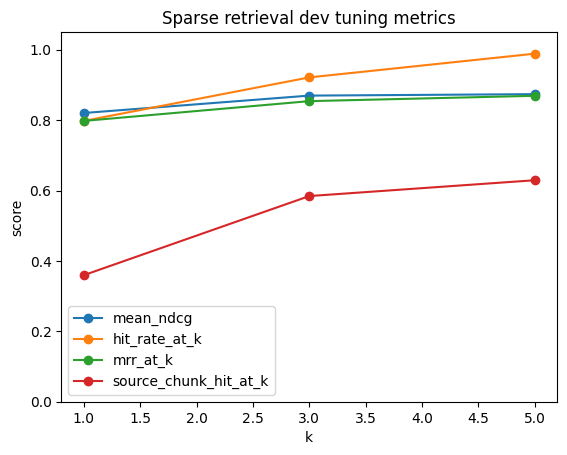

In [64]:
# Tune sparse retrieval top-k with LLM-judged graded relevance.
# Retrieval only receives query/query_id; expected information is used only after retrieval.
RUN_SPARSE_TOP_K_TUNING = False
BEST_SPARSE_RETRIEVAL_TOP_K = 5  # Selected from the retained dev tuning results.

if not RUN_SPARSE_TOP_K_TUNING:
    print(f"Skipping sparse tuning; using retained top-k={BEST_SPARSE_RETRIEVAL_TOP_K}.")
else:
    if relevance_judge_llm is None:
        raise RuntimeError("Initialize relevance_judge_llm in section 1.3 first.")

    sparse_dev_retrieval_results_df = retrieve_for_qrels(
        sparse_tuning_eval_qrels_df,
        qdrant_sparse_retriever,
        top_k=SPARSE_TUNING_MAX_K,
        verbose=True,
    )

    display(sparse_dev_retrieval_results_df.groupby("query_id").size().describe().to_frame("retrieved_per_query"))

    sparse_dev_judgments_df = judge_retrieval_results(
        sparse_dev_retrieval_results_df,
        sparse_tuning_eval_qrels_df,
        relevance_judge_llm,
        output_jsonl=SPARSE_DEV_JUDGMENTS_JSONL,
        resume=True,
        max_new_tokens=SPARSE_JUDGE_MAX_NEW_TOKENS,
        max_retries=SPARSE_JUDGE_MAX_RETRIES,
        retry_sleep_seconds=SPARSE_JUDGE_RETRY_SLEEP_SECONDS,
        verbose=True,
    )

    sparse_tuning_metrics_df = summarize_retrieval_judgments(
        sparse_dev_judgments_df,
        k_values=SPARSE_RETRIEVAL_TOP_K_CANDIDATES,
        relevance_threshold=SPARSE_TUNING_RELEVANCE_THRESHOLD,
    )

    display(sparse_tuning_metrics_df)

    sparse_tuning_plot_ax = sparse_tuning_metrics_df.plot(
        x="k",
        y=["mean_ndcg", "hit_rate_at_k", "mrr_at_k", "source_chunk_hit_at_k"],
        marker="o",
        title="Sparse retrieval dev tuning metrics",
    )
    sparse_tuning_plot_ax.set_ylabel("score")
    sparse_tuning_plot_ax.set_ylim(0, 1.05)

    best_sparse_threshold_row = sparse_tuning_metrics_df.sort_values(
        ["mean_ndcg", "hit_rate_at_k", "mrr_at_k"],
        ascending=False,
    ).iloc[0]
    BEST_SPARSE_RETRIEVAL_TOP_K = int(best_sparse_threshold_row["k"])
    print(f"Best sparse top-k by dev mean nDCG: {BEST_SPARSE_RETRIEVAL_TOP_K}")
    display(best_sparse_threshold_row.to_frame().T)


#### 2.1.2. Smoke test

In [11]:
SPARSE_VECTOR_NAME = "sparse"
SPARSE_QUERY_EMBEDDING_MAX_LENGTH = 1024

if "qdrant_retrieval_driver" not in globals():
    raise RuntimeError("Initialize qdrant_retrieval_driver in section 1.2.2 first.")

if "sparse_query_embedder" not in globals():
    # Lazy import keeps the notebook startup light while other long-running jobs are active.
    from src.bge_m3_embedding import BGEM3Embedder
    sparse_query_embedder = BGEM3Embedder(
        device="cuda" if torch.cuda.is_available() else "cpu",
        require_cuda=False,
    )
    print(f"Loaded sparse query embedder on: {sparse_query_embedder.device}")

if "qdrant_sparse_retriever" not in globals():
    qdrant_sparse_retriever = QdrantSparseRetriever(
        qdrant_driver=qdrant_retrieval_driver,
        embedder=sparse_query_embedder,
        vector_name=SPARSE_VECTOR_NAME,
        embedding_max_length=SPARSE_QUERY_EMBEDDING_MAX_LENGTH,
    )

sparse_smoke_results_df = qdrant_sparse_retriever.retrieve(
    RETRIEVAL_SMOKE_TEST_QUERY,
    query_id=RETRIEVAL_SMOKE_TEST_QUERY_ID,
    top_k=BEST_SPARSE_RETRIEVAL_TOP_K,
)

display(sparse_smoke_results_df[[
    "rank",
    "score",
    "chunk_id",
    "dataset",
    "modality",
    "title",
    "retrieval_text_preview",
]])

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 55.56it/s]
You're using a XLMRobertaTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.
Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 32.22it/s]


,rank,score,chunk_id,dataset,modality,title,retrieval_text_preview
0,1,0.226746,e6be75d4356e2c23cc1e1370,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...
1,2,0.221275,84826471808b8a1a3335a73b,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...
2,3,0.216745,cda827e281f3e728d26877de,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...
3,4,0.214957,940efcd4a433ba1f46ccdb58,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...
4,5,0.209537,be839e1bf2c072527ae0b4c7,cnn_dailymail,article,CNN/DailyMail Article 2fe159232cbb,Dataset: cnn_dailymail\nModality: article\nTit...


In [12]:
# Inspect the full text for the top sparse retrieval results.
SPARSE_SMOKE_PREVIEW_TOP_N = 5

if "sparse_smoke_results_df" not in globals() or sparse_smoke_results_df.empty:
    raise RuntimeError("Run the sparse smoke-test retrieval cell first.")

for _, row in sparse_smoke_results_df.head(SPARSE_SMOKE_PREVIEW_TOP_N).iterrows():
    print("=" * 100)
    print(f"Rank {int(row['rank'])} | score={row['score']:.4f} | chunk_id={row['chunk_id']}")
    print(f"Dataset={row['dataset']} | Modality={row['modality']} | Document={row['document_id']}")
    print(f"Title: {row['title']}")
    print("-" * 100)
    print(str(row.get("retrieval_text", ""))[:3000])
    print()

Rank 1 | score=0.2267 | chunk_id=e6be75d4356e2c23cc1e1370
Dataset=cnn_dailymail | Modality=article | Document=2dd89e248d507aacb58404d3
Title: CNN/DailyMail Article 0348c10a8212
----------------------------------------------------------------------------------------------------
Dataset: cnn_dailymail
Modality: article
Title: CNN/DailyMail Article 0348c10a8212
Summary: NEW: ACLU calls drone attacks part of illegal program for U.S. to target, kill terror suspects .
Since President Obama took office, number of drone attacks has risen .
U.S. law professors debate legality of such attacks during a House subcommittee hearing .
Biggest controversy: legality of strikes conducted by CIA, as opposed to U.S. military .
Metadata: {"hf_dataset": "abisee/cnn_dailymail", "hf_config": "3.0.0", "hf_split": "train", "original_fields": ["article", "highlights", "id"]}
Content: John Tierney, D-Massachusetts, the subcommittee's chairman. "Our interpretation of how these standards apply to the use of unmanne

### 2.2. Dense Retrieval

#### 2.2.1. Tune top-k

In [13]:
from importlib import reload

import src.retrieval_dense as dense_retrieval_helpers
reload(dense_retrieval_helpers)

from src.retrieval_dense import QdrantDenseRetriever

Dense retrieval cache entries: 20


Retrieving dev queries @ 5:   0%|          | 0/89 [00:00<?, ?query/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 12.20it/s]


Judging retrieved chunks:   0%|          | 0/445 [00:00<?, ?result/s]

,strategy,k,queries,judged_results,mean_ndcg,precision_at_k,hit_rate_at_k,mrr_at_k,source_chunk_hit_at_k,relevance_threshold
0,dense,1,89,89,0.831461,0.752809,0.752809,0.702247,0.314607,2
1,dense,3,89,267,0.847150,0.681648,0.921348,0.782772,0.516854,2
2,dense,5,89,445,0.842772,0.633708,0.943820,0.787828,0.561798,2


Best dense top-k by dev mean nDCG: 3


,strategy,k,queries,judged_results,mean_ndcg,precision_at_k,hit_rate_at_k,mrr_at_k,source_chunk_hit_at_k,relevance_threshold
1,dense,3,89,267,0.84715,0.681648,0.921348,0.782772,0.516854,2


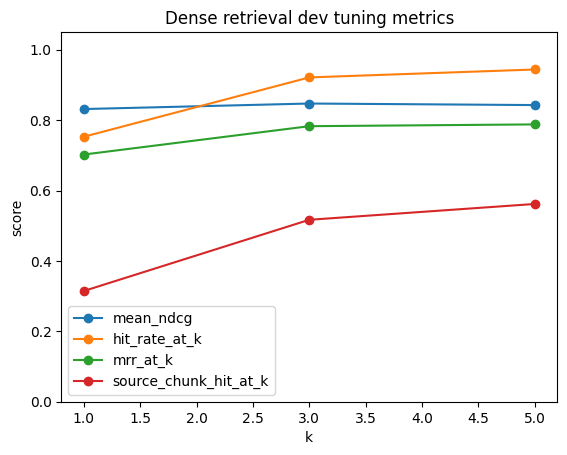

In [66]:
# Tune dense retrieval top-k with the same dev qrels and judge cache pattern as sparse retrieval.
DENSE_VECTOR_NAME = "dense"
DENSE_QUERY_EMBEDDING_MAX_LENGTH = 1024
DENSE_RETRIEVAL_TOP_K_CANDIDATES = SPARSE_RETRIEVAL_TOP_K_CANDIDATES if "SPARSE_RETRIEVAL_TOP_K_CANDIDATES" in globals() else [1, 3, 5]
DENSE_TUNING_RELEVANCE_THRESHOLD = SPARSE_TUNING_RELEVANCE_THRESHOLD if "SPARSE_TUNING_RELEVANCE_THRESHOLD" in globals() else 2
DENSE_JUDGE_MAX_NEW_TOKENS = SPARSE_JUDGE_MAX_NEW_TOKENS if "SPARSE_JUDGE_MAX_NEW_TOKENS" in globals() else 1024
DENSE_JUDGE_MAX_RETRIES = SPARSE_JUDGE_MAX_RETRIES if "SPARSE_JUDGE_MAX_RETRIES" in globals() else 5
DENSE_JUDGE_RETRY_SLEEP_SECONDS = SPARSE_JUDGE_RETRY_SLEEP_SECONDS if "SPARSE_JUDGE_RETRY_SLEEP_SECONDS" in globals() else 2.0
DENSE_DEV_JUDGMENTS_JSONL = RETRIEVAL_DEV_JUDGMENTS_JSONL

if "sparse_tuning_eval_qrels_df" not in globals():
    RETRIEVAL_QRELS_DEV_JSONL = Path("data/evaluation/retrieval_queries/retrieval_qrels_dev.jsonl")
    sparse_tuning_eval_qrels_df = load_retrieval_qrels(RETRIEVAL_QRELS_DEV_JSONL, valid_only=True)

if "bge_m3_query_embedder" not in globals():
    if "sparse_query_embedder" in globals():
        bge_m3_query_embedder = sparse_query_embedder
    else:
        from src.bge_m3_embedding import BGEM3Embedder
        bge_m3_query_embedder = BGEM3Embedder(
            device="cuda" if torch.cuda.is_available() else "cpu",
            require_cuda=False,
        )
        print(f"Loaded BGE-M3 query embedder on: {bge_m3_query_embedder.device}")

if "qdrant_dense_retriever" not in globals():
    qdrant_dense_retriever = QdrantDenseRetriever(
        qdrant_driver=qdrant_retrieval_driver,
        embedder=bge_m3_query_embedder,
        vector_name=DENSE_VECTOR_NAME,
        embedding_max_length=DENSE_QUERY_EMBEDDING_MAX_LENGTH,
    )
print(f"Dense retrieval cache entries: {len(qdrant_dense_retriever.retrieval_cache)}")

RUN_DENSE_TOP_K_TUNING = False
if RUN_DENSE_TOP_K_TUNING:
    dense_dev_retrieval_results_df, dense_dev_judgments_df, dense_tuning_metrics_df, best_dense_top_k_row = tune_retriever_top_k(
        strategy_name="dense",
        qrels_df=sparse_tuning_eval_qrels_df,
        retriever=qdrant_dense_retriever,
        judge_llm=relevance_judge_llm,
        top_k_candidates=DENSE_RETRIEVAL_TOP_K_CANDIDATES,
        judgments_jsonl=DENSE_DEV_JUDGMENTS_JSONL,
        relevance_threshold=DENSE_TUNING_RELEVANCE_THRESHOLD,
        max_new_tokens=DENSE_JUDGE_MAX_NEW_TOKENS,
        max_retries=DENSE_JUDGE_MAX_RETRIES,
        retry_sleep_seconds=DENSE_JUDGE_RETRY_SLEEP_SECONDS,
        verbose=True,
    )
    display(dense_tuning_metrics_df)
    dense_tuning_plot_ax = dense_tuning_metrics_df.plot(
        x="k",
        y=["mean_ndcg", "hit_rate_at_k", "mrr_at_k", "source_chunk_hit_at_k"],
        marker="o",
        title="Dense retrieval dev tuning metrics",
    )
    dense_tuning_plot_ax.set_ylabel("score")
    dense_tuning_plot_ax.set_ylim(0, 1.05)
    BEST_DENSE_RETRIEVAL_TOP_K = int(best_dense_top_k_row["k"])
    print(f"Best dense top-k by dev mean nDCG: {BEST_DENSE_RETRIEVAL_TOP_K}")
    display(best_dense_top_k_row.to_frame().T)
else:
    BEST_DENSE_RETRIEVAL_TOP_K = 3
    print(f"Skipping dense tuning; using retained top-k={BEST_DENSE_RETRIEVAL_TOP_K}.")


#### 2.2.2. Smoke test

In [16]:
DENSE_VECTOR_NAME = "dense"
DENSE_QUERY_EMBEDDING_MAX_LENGTH = 1024

if "qdrant_retrieval_driver" not in globals():
    raise RuntimeError("Initialize qdrant_retrieval_driver in section 1.2.2 first.")

if "bge_m3_query_embedder" not in globals():
    if "sparse_query_embedder" in globals():
        bge_m3_query_embedder = sparse_query_embedder
        print(f"Reusing BGE-M3 query embedder on: {bge_m3_query_embedder.device}")
    else:
        from src.bge_m3_embedding import BGEM3Embedder
        bge_m3_query_embedder = BGEM3Embedder(
            device="cuda" if torch.cuda.is_available() else "cpu",
            require_cuda=False,
        )
        print(f"Loaded BGE-M3 query embedder on: {bge_m3_query_embedder.device}")

if "qdrant_dense_retriever" not in globals():
    qdrant_dense_retriever = QdrantDenseRetriever(
        qdrant_driver=qdrant_retrieval_driver,
        embedder=bge_m3_query_embedder,
        vector_name=DENSE_VECTOR_NAME,
        embedding_max_length=DENSE_QUERY_EMBEDDING_MAX_LENGTH,
    )

dense_smoke_results_df = qdrant_dense_retriever.retrieve(
    RETRIEVAL_SMOKE_TEST_QUERY,
    query_id=RETRIEVAL_SMOKE_TEST_QUERY_ID,
    top_k=BEST_DENSE_RETRIEVAL_TOP_K,
)

display(dense_smoke_results_df[[
    "rank",
    "score",
    "chunk_id",
    "dataset",
    "modality",
    "title",
    "retrieval_text_preview",
]])

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 11.95it/s]


,rank,score,chunk_id,dataset,modality,title,retrieval_text_preview
0,1,0.734324,84826471808b8a1a3335a73b,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...
1,2,0.725239,e6be75d4356e2c23cc1e1370,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...
2,3,0.700272,cda827e281f3e728d26877de,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...


In [17]:
# Inspect the full text for the top dense retrieval results.
DENSE_SMOKE_PREVIEW_TOP_N = 3

if "dense_smoke_results_df" not in globals() or dense_smoke_results_df.empty:
    raise RuntimeError("Run the dense smoke-test retrieval cell first.")

for _, row in dense_smoke_results_df.head(DENSE_SMOKE_PREVIEW_TOP_N).iterrows():
    print("=" * 100)
    print(f"Rank {int(row['rank'])} | score={row['score']:.4f} | chunk_id={row['chunk_id']}")
    print(f"Dataset={row['dataset']} | Modality={row['modality']} | Document={row['document_id']}")
    print(f"Title: {row['title']}")
    print("-" * 100)
    print(str(row.get("retrieval_text", ""))[:3000])
    print()

Rank 1 | score=0.7343 | chunk_id=84826471808b8a1a3335a73b
Dataset=cnn_dailymail | Modality=article | Document=2dd89e248d507aacb58404d3
Title: CNN/DailyMail Article 0348c10a8212
----------------------------------------------------------------------------------------------------
Dataset: cnn_dailymail
Modality: article
Title: CNN/DailyMail Article 0348c10a8212
Summary: NEW: ACLU calls drone attacks part of illegal program for U.S. to target, kill terror suspects .
Since President Obama took office, number of drone attacks has risen .
U.S. law professors debate legality of such attacks during a House subcommittee hearing .
Biggest controversy: legality of strikes conducted by CIA, as opposed to U.S. military .
Metadata: {"hf_dataset": "abisee/cnn_dailymail", "hf_config": "3.0.0", "hf_split": "train", "original_fields": ["article", "highlights", "id"]}
Content: And most importantly, they are not trained in the law of armed conflict." O'Connell also said that "we know from empirical data ..

### 2.3. Hybrid Dense-Sparse Retrieval

#### 2.3.1. Tune top-k

In [18]:
from importlib import reload

import src.retrieval_hybrid as hybrid_retrieval_helpers
reload(hybrid_retrieval_helpers)

from src.retrieval_hybrid import QdrantHybridRrfRetriever

Tuning hybrid prefetch:   0%|          | 0/2 [00:00<?, ?config/s]

Hybrid retrieval cache entries for prefetch=3: 10


Retrieving dev queries @ 5:   0%|          | 0/89 [00:00<?, ?query/s]


pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 998.88it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 11.76it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 1001.03it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 12.66it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 999.36it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 11.77it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 999.36it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 12.34it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 1001.03it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 12.05it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<?, ?it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 14.07it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 1002.46it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 10.64it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 1020.51it/s]

Inference Embeddings: 100

Judging retrieved chunks:   0%|          | 0/445 [00:00<?, ?result/s]

...


pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 1001.51it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 10.36it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 1000.79it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 10.81it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 999.36it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 13.89it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<?, ?it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 13.07it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 1000.55it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 14.67it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 1001.27it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 14.74it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 999.36it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 13.42it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<?, ?it/s]

Inference Embeddings: 100%|███████

Judging retrieved chunks:   0%|          | 0/445 [00:00<?, ?result/s]

,strategy,k,queries,judged_results,mean_ndcg,precision_at_k,hit_rate_at_k,mrr_at_k,source_chunk_hit_at_k,relevance_threshold,prefetch_multiplier
0,hybrid_rrf_prefetch_3,1,89,89,0.831461,0.797753,0.797753,0.797753,0.359551,2,3
1,hybrid_rrf_prefetch_3,3,89,267,0.879536,0.704120,0.943820,0.915730,0.595506,2,3
2,hybrid_rrf_prefetch_3,5,89,445,0.870950,0.647191,0.966292,0.922285,0.696629,2,3
3,hybrid_rrf_prefetch_5,1,89,89,0.831461,0.797753,0.797753,0.797753,0.359551,2,5
4,hybrid_rrf_prefetch_5,3,89,267,0.870095,0.696629,0.932584,0.910112,0.595506,2,5
5,hybrid_rrf_prefetch_5,5,89,445,0.864986,0.656180,0.966292,0.922285,0.696629,2,5


Best hybrid top-k: 3
Best hybrid prefetch multiplier: 3


,strategy,k,queries,judged_results,mean_ndcg,precision_at_k,hit_rate_at_k,mrr_at_k,source_chunk_hit_at_k,relevance_threshold,prefetch_multiplier
1,hybrid_rrf_prefetch_3,3,89,267,0.879536,0.70412,0.94382,0.91573,0.595506,2,3


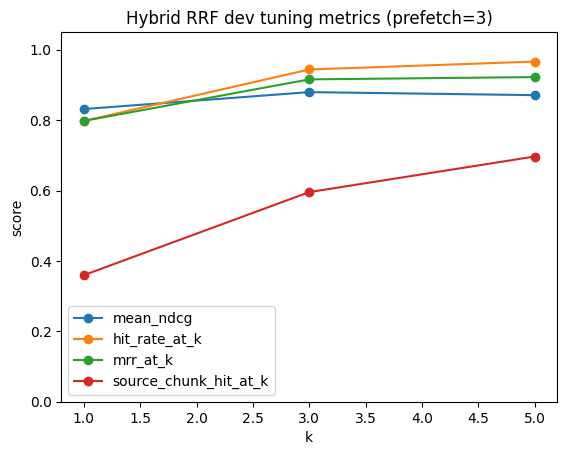

In [68]:
# Tune hybrid RRF top-k and a small prefetch-multiplier grid.
HYBRID_DENSE_VECTOR_NAME = "dense"
HYBRID_SPARSE_VECTOR_NAME = "sparse"
HYBRID_QUERY_EMBEDDING_MAX_LENGTH = 1024
HYBRID_RETRIEVAL_TOP_K_CANDIDATES = SPARSE_RETRIEVAL_TOP_K_CANDIDATES if "SPARSE_RETRIEVAL_TOP_K_CANDIDATES" in globals() else [1, 3, 5]
HYBRID_PREFETCH_MULTIPLIER_CANDIDATES = [3, 5]
HYBRID_TUNING_RELEVANCE_THRESHOLD = SPARSE_TUNING_RELEVANCE_THRESHOLD if "SPARSE_TUNING_RELEVANCE_THRESHOLD" in globals() else 2
HYBRID_DEV_JUDGMENTS_JSONL = RETRIEVAL_DEV_JUDGMENTS_JSONL

if "bge_m3_query_embedder" not in globals():
    if "sparse_query_embedder" in globals():
        bge_m3_query_embedder = sparse_query_embedder
    else:
        from src.bge_m3_embedding import BGEM3Embedder
        bge_m3_query_embedder = BGEM3Embedder(
            device="cuda" if torch.cuda.is_available() else "cpu",
            require_cuda=False,
        )

RUN_HYBRID_TOP_K_TUNING = False
if "hybrid_tuning_retrievers" not in globals():
    hybrid_tuning_retrievers = {}
hybrid_tuning_metric_frames = []
hybrid_tuning_runs = {}
if RUN_HYBRID_TOP_K_TUNING:
    for prefetch_multiplier in tqdm(HYBRID_PREFETCH_MULTIPLIER_CANDIDATES, desc="Tuning hybrid prefetch", unit="config"):
        hybrid_cache_key = (prefetch_multiplier,)
        if hybrid_cache_key not in hybrid_tuning_retrievers:
            hybrid_tuning_retrievers[hybrid_cache_key] = QdrantHybridRrfRetriever(
                qdrant_driver=qdrant_retrieval_driver,
                embedder=bge_m3_query_embedder,
                dense_vector_name=HYBRID_DENSE_VECTOR_NAME,
                sparse_vector_name=HYBRID_SPARSE_VECTOR_NAME,
                embedding_max_length=HYBRID_QUERY_EMBEDDING_MAX_LENGTH,
                prefetch_multiplier=prefetch_multiplier,
            )
        candidate_hybrid_retriever = hybrid_tuning_retrievers[hybrid_cache_key]
        tqdm.write(
            f"Hybrid retrieval cache entries for prefetch={prefetch_multiplier}: "
            f"{len(candidate_hybrid_retriever.retrieval_cache)}"
        )
        retrieval_df, judgments_df, metrics_df, best_row = tune_retriever_top_k(
            strategy_name=f"hybrid_rrf_prefetch_{prefetch_multiplier}",
            qrels_df=sparse_tuning_eval_qrels_df,
            retriever=candidate_hybrid_retriever,
            judge_llm=relevance_judge_llm,
            top_k_candidates=HYBRID_RETRIEVAL_TOP_K_CANDIDATES,
            judgments_jsonl=HYBRID_DEV_JUDGMENTS_JSONL,
            relevance_threshold=HYBRID_TUNING_RELEVANCE_THRESHOLD,
            max_new_tokens=SPARSE_JUDGE_MAX_NEW_TOKENS,
            max_retries=SPARSE_JUDGE_MAX_RETRIES,
            retry_sleep_seconds=SPARSE_JUDGE_RETRY_SLEEP_SECONDS,
            verbose=True,
        )
        metrics_df["prefetch_multiplier"] = prefetch_multiplier
        hybrid_tuning_metric_frames.append(metrics_df)
        hybrid_tuning_runs[prefetch_multiplier] = (retrieval_df, judgments_df, metrics_df, best_row)

    hybrid_tuning_metrics_df = pd.concat(hybrid_tuning_metric_frames, ignore_index=True)
    display(hybrid_tuning_metrics_df)
    best_hybrid_prefetch_for_plot = hybrid_tuning_metrics_df.sort_values(
        ["mean_ndcg", "hit_rate_at_k", "mrr_at_k"],
        ascending=False,
    ).iloc[0]["prefetch_multiplier"]
    hybrid_tuning_plot_df = hybrid_tuning_metrics_df[
        hybrid_tuning_metrics_df["prefetch_multiplier"] == best_hybrid_prefetch_for_plot
    ].copy()
    hybrid_tuning_plot_ax = hybrid_tuning_plot_df.plot(
        x="k",
        y=["mean_ndcg", "hit_rate_at_k", "mrr_at_k", "source_chunk_hit_at_k"],
        marker="o",
        title=f"Hybrid RRF dev tuning metrics (prefetch={best_hybrid_prefetch_for_plot})",
    )
    hybrid_tuning_plot_ax.set_ylabel("score")
    hybrid_tuning_plot_ax.set_ylim(0, 1.05)

    best_hybrid_row = hybrid_tuning_metrics_df.sort_values(
        ["mean_ndcg", "hit_rate_at_k", "mrr_at_k"],
        ascending=False,
    ).iloc[0]
    BEST_HYBRID_RETRIEVAL_TOP_K = int(best_hybrid_row["k"])
    BEST_HYBRID_PREFETCH_MULTIPLIER = int(best_hybrid_row["prefetch_multiplier"])
    print(f"Best hybrid top-k: {BEST_HYBRID_RETRIEVAL_TOP_K}")
    print(f"Best hybrid prefetch multiplier: {BEST_HYBRID_PREFETCH_MULTIPLIER}")
    display(best_hybrid_row.to_frame().T)
else:
    BEST_HYBRID_RETRIEVAL_TOP_K = 3
    BEST_HYBRID_PREFETCH_MULTIPLIER = 3
    print(
        "Skipping hybrid tuning; using retained "
        f"top-k={BEST_HYBRID_RETRIEVAL_TOP_K}, "
        f"prefetch={BEST_HYBRID_PREFETCH_MULTIPLIER}."
    )

qdrant_hybrid_retriever = QdrantHybridRrfRetriever(
    qdrant_driver=qdrant_retrieval_driver,
    embedder=bge_m3_query_embedder,
    dense_vector_name=HYBRID_DENSE_VECTOR_NAME,
    sparse_vector_name=HYBRID_SPARSE_VECTOR_NAME,
    embedding_max_length=HYBRID_QUERY_EMBEDDING_MAX_LENGTH,
    prefetch_multiplier=BEST_HYBRID_PREFETCH_MULTIPLIER,
)


#### 2.3.2. Smoke test

In [24]:
HYBRID_DENSE_VECTOR_NAME = "dense"
HYBRID_SPARSE_VECTOR_NAME = "sparse"
HYBRID_QUERY_EMBEDDING_MAX_LENGTH = 1024

if "qdrant_retrieval_driver" not in globals():
    raise RuntimeError("Initialize qdrant_retrieval_driver in section 1.2.2 first.")

if "bge_m3_query_embedder" not in globals():
    if "sparse_query_embedder" in globals():
        bge_m3_query_embedder = sparse_query_embedder
        print(f"Reusing BGE-M3 query embedder on: {bge_m3_query_embedder.device}")
    else:
        from src.bge_m3_embedding import BGEM3Embedder
        bge_m3_query_embedder = BGEM3Embedder(
            device="cuda" if torch.cuda.is_available() else "cpu",
            require_cuda=False,
        )
        print(f"Loaded BGE-M3 query embedder on: {bge_m3_query_embedder.device}")

if "qdrant_hybrid_retriever" not in globals():
    qdrant_hybrid_retriever = QdrantHybridRrfRetriever(
        qdrant_driver=qdrant_retrieval_driver,
        embedder=bge_m3_query_embedder,
        dense_vector_name=HYBRID_DENSE_VECTOR_NAME,
        sparse_vector_name=HYBRID_SPARSE_VECTOR_NAME,
        embedding_max_length=HYBRID_QUERY_EMBEDDING_MAX_LENGTH,
        prefetch_multiplier=BEST_HYBRID_PREFETCH_MULTIPLIER,
    )

hybrid_smoke_results_df = qdrant_hybrid_retriever.retrieve(
    RETRIEVAL_SMOKE_TEST_QUERY,
    query_id=RETRIEVAL_SMOKE_TEST_QUERY_ID,
    top_k=BEST_HYBRID_RETRIEVAL_TOP_K,
)

display(hybrid_smoke_results_df[[
    "rank",
    "score",
    "chunk_id",
    "dataset",
    "modality",
    "title",
    "retrieval_text_preview",
]])

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 999.83it/s]


Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 11.90it/s]


,rank,score,chunk_id,dataset,modality,title,retrieval_text_preview
0,1,0.833333,84826471808b8a1a3335a73b,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...
1,2,0.833333,e6be75d4356e2c23cc1e1370,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...
2,3,0.500000,cda827e281f3e728d26877de,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...


In [25]:
# Inspect the full text for the top hybrid retrieval results.
HYBRID_SMOKE_PREVIEW_TOP_N = 3

if "hybrid_smoke_results_df" not in globals() or hybrid_smoke_results_df.empty:
    raise RuntimeError("Run the hybrid smoke-test retrieval cell first.")

for _, row in hybrid_smoke_results_df.head(HYBRID_SMOKE_PREVIEW_TOP_N).iterrows():
    print("=" * 100)
    print(f"Rank {int(row['rank'])} | score={row['score']:.4f} | chunk_id={row['chunk_id']}")
    print(f"Dataset={row['dataset']} | Modality={row['modality']} | Document={row['document_id']}")
    print(f"Title: {row['title']}")
    print("-" * 100)
    print(str(row.get("retrieval_text", ""))[:3000])
    print()

Rank 1 | score=0.8333 | chunk_id=84826471808b8a1a3335a73b
Dataset=cnn_dailymail | Modality=article | Document=2dd89e248d507aacb58404d3
Title: CNN/DailyMail Article 0348c10a8212
----------------------------------------------------------------------------------------------------
Dataset: cnn_dailymail
Modality: article
Title: CNN/DailyMail Article 0348c10a8212
Summary: NEW: ACLU calls drone attacks part of illegal program for U.S. to target, kill terror suspects .
Since President Obama took office, number of drone attacks has risen .
U.S. law professors debate legality of such attacks during a House subcommittee hearing .
Biggest controversy: legality of strikes conducted by CIA, as opposed to U.S. military .
Metadata: {"hf_dataset": "abisee/cnn_dailymail", "hf_config": "3.0.0", "hf_split": "train", "original_fields": ["article", "highlights", "id"]}
Content: And most importantly, they are not trained in the law of armed conflict." O'Connell also said that "we know from empirical data ..

### 2.4. Graph-Expanded Hybrid Retrieval

#### 2.4.1. Tune top-k

In [26]:
from importlib import reload

import src.retrieval_drivers as retrieval_driver_helpers
import src.retrieval_graph as graph_retrieval_helpers
import src.retrieval_hybrid as hybrid_retrieval_helpers

reload(retrieval_driver_helpers)
reload(hybrid_retrieval_helpers)
reload(graph_retrieval_helpers)

from src.retrieval_drivers import Neo4jGraphRetrievalDriver, QdrantRetrievalDriver
from src.retrieval_graph import GraphExpandedHybridRetriever, GraphQueryExpander, require_model_on_cuda, model_device_summary
from src.retrieval_hybrid import QdrantHybridRrfRetriever

In [28]:
# Load the same GLiNER/ReFinED query-understanding stack used in the Database notebook.
GRAPH_QUERY_DEBUG = True
GRAPH_QUERY_USE_GLINER = True
GRAPH_QUERY_USE_REFINED = True
GRAPH_QUERY_REQUIRE_CUDA = True
GRAPH_QUERY_GLINER_MODEL_NAME = "urchade/gliner_medium-v2.1"
GRAPH_QUERY_GLINER_LOCAL_MODEL_DIR = Path("data") / "model_cache" / "gliner_medium_v2_1"
GRAPH_QUERY_GLINER_THRESHOLD = 0.4
GRAPH_QUERY_LABEL_SET_VERSION = "v4"
GRAPH_QUERY_MENTION_LABELS = [
    "person",
    "organization",
    "location",
    "date",
    "event",
    "product or brand",
    "creative work title",
    "law or regulation",
    "nationality",
    "religious group",
    "political group",
    "language",
    "program or initiative",
]
GRAPH_QUERY_REFINED_EXPERIMENT_DIR = (
    Path("data")
    / "graph_kb_exports"
    / "step_03_canonicalization"
    / "fine_tuned_refined_models"
    / "archive_canonicalization_refined"
)
GRAPH_QUERY_REFINED_ENTITY_SET = "wikipedia"
GRAPH_QUERY_REFINED_MIN_LINK_SCORE = 0.0

if "qdrant_retrieval_driver" not in globals() or not hasattr(qdrant_retrieval_driver, "search_hybrid_rrf"):
    qdrant_retrieval_driver = QdrantRetrievalDriver.from_environment(
        env_path=".env",
        use_colab_userdata=True,
        default_collection_name="archive-chunks",
    )
    COLLECTION_NAME = qdrant_retrieval_driver.collection_name

if "neo4j_graph_driver" not in globals() or not hasattr(neo4j_graph_driver, "graph_expansion_hints"):
    neo4j_graph_driver = Neo4jGraphRetrievalDriver.from_environment(
        env_path=".env",
        use_colab_userdata=True,
    )
    neo4j_graph_driver.verify_connectivity()

if "bge_m3_query_embedder" not in globals():
    if "sparse_query_embedder" in globals():
        bge_m3_query_embedder = sparse_query_embedder
        print(f"Reusing BGE-M3 query embedder on: {bge_m3_query_embedder.device}")
    else:
        from src.bge_m3_embedding import BGEM3Embedder
        bge_m3_query_embedder = BGEM3Embedder(
            device="cuda" if torch.cuda.is_available() else "cpu",
            require_cuda=False,
        )
        print(f"Loaded BGE-M3 query embedder on: {bge_m3_query_embedder.device}")

if GRAPH_QUERY_USE_GLINER and "graph_query_gliner_model" not in globals():
    from huggingface_hub import snapshot_download
    from gliner import GLiNER

    GRAPH_QUERY_GLINER_LOCAL_MODEL_DIR.mkdir(parents=True, exist_ok=True)
    try:
        snapshot_download(
            repo_id=GRAPH_QUERY_GLINER_MODEL_NAME,
            local_dir=str(GRAPH_QUERY_GLINER_LOCAL_MODEL_DIR),
            local_dir_use_symlinks=False,
        )
    except TypeError:
        snapshot_download(
            repo_id=GRAPH_QUERY_GLINER_MODEL_NAME,
            local_dir=str(GRAPH_QUERY_GLINER_LOCAL_MODEL_DIR),
        )
    graph_query_gliner_model = GLiNER.from_pretrained(str(GRAPH_QUERY_GLINER_LOCAL_MODEL_DIR))
    graph_query_gliner_device = "cuda" if torch.cuda.is_available() else "cpu"
    if GRAPH_QUERY_REQUIRE_CUDA and not torch.cuda.is_available():
        raise RuntimeError("GRAPH_QUERY_REQUIRE_CUDA=True, but PyTorch cannot see CUDA.")
    graph_query_gliner_model.to(graph_query_gliner_device)
    graph_query_gliner_model.eval()
    if GRAPH_QUERY_REQUIRE_CUDA:
        require_model_on_cuda(graph_query_gliner_model, model_name="graph-query GLiNER")
    print(f"Loaded graph-query GLiNER on: {model_device_summary(graph_query_gliner_model)}")

if GRAPH_QUERY_USE_REFINED and "graph_query_refined_model" not in globals():
    refined_checkpoint_dirs = sorted(
        GRAPH_QUERY_REFINED_EXPERIMENT_DIR.glob("f1_*"),
        key=lambda path: path.name,
        reverse=True,
    )
    if not refined_checkpoint_dirs:
        raise FileNotFoundError(
            f"No fine-tuned ReFinED checkpoint found under {GRAPH_QUERY_REFINED_EXPERIMENT_DIR}"
        )
    GRAPH_QUERY_REFINED_MODEL_DIR = refined_checkpoint_dirs[0]
    from src.refined_canonicalization import load_refined_model
    if GRAPH_QUERY_REQUIRE_CUDA and not torch.cuda.is_available():
        raise RuntimeError("GRAPH_QUERY_REQUIRE_CUDA=True, but PyTorch cannot see CUDA.")
    graph_query_refined_model = load_refined_model(
        model_name=str(GRAPH_QUERY_REFINED_MODEL_DIR.resolve()),
        entity_set=GRAPH_QUERY_REFINED_ENTITY_SET,
        use_precomputed_descriptions=False,
        device="cuda:0" if torch.cuda.is_available() else "cpu",
    )
    if GRAPH_QUERY_REQUIRE_CUDA:
        require_model_on_cuda(graph_query_refined_model, model_name="graph-query ReFinED")
    print(f"Loaded graph-query ReFinED checkpoint: {GRAPH_QUERY_REFINED_MODEL_DIR}")
    print(f"Graph-query ReFinED device: {model_device_summary(graph_query_refined_model)}")

22:23:23 - refined.inference.processor - INFO - Precomputed entity description embeddings cannot be loaded from from D:\GitHub\Design-and-Evaluation-of-Secure-Retrieval-Augmented-Systems-for-Large-Scale-Digital-Archives\data\graph_kb_exports\step_03_canonicalization\fine_tuned_refined_models\archive_canonicalization_refined\f1_0.0769\precomputed_entity_descriptions_emb_wikipedia_6269457-300.np Use precompute_description_embeddings.py script to generate these embeddings to get a significant inference speed improvement.
Loaded graph-query ReFinED checkpoint: data\graph_kb_exports\step_03_canonicalization\fine_tuned_refined_models\archive_canonicalization_refined\f1_0.0769
Graph-query ReFinED device: cuda:0


In [30]:
# Tune graph-expanded hybrid retrieval with a bounded grid.
GRAPH_EXPANDED_DENSE_VECTOR_NAME = "dense"
GRAPH_EXPANDED_SPARSE_VECTOR_NAME = "sparse"
GRAPH_EXPANDED_QUERY_EMBEDDING_MAX_LENGTH = 1024
GRAPH_EXPANDED_HYBRID_TOP_K_CANDIDATES = SPARSE_RETRIEVAL_TOP_K_CANDIDATES if "SPARSE_RETRIEVAL_TOP_K_CANDIDATES" in globals() else [1, 3, 5]
GRAPH_EXPANDED_PREFETCH_MULTIPLIER_CANDIDATES = [3, 5]
BEST_GRAPH_EXPANDED_ENTITY_LIMIT = 8
BEST_GRAPH_EXPANDED_ALIAS_LIMIT = 8
BEST_GRAPH_EXPANDED_NEIGHBOR_LIMIT = 12
BEST_GRAPH_EXPANDED_VARIANT_RRF_K = 60
GRAPH_EXPANDED_DEV_JUDGMENTS_JSONL = RETRIEVAL_DEV_JUDGMENTS_JSONL

RUN_GRAPH_EXPANDED_TOP_K_TUNING = False
GRAPH_EXPANDED_TUNING_DEBUG = False
if "graph_expanded_tuning_retrievers" not in globals():
    graph_expanded_tuning_retrievers = {}

graph_expanded_tuning_metric_frames = []
if RUN_GRAPH_EXPANDED_TOP_K_TUNING:
    for prefetch_multiplier in tqdm(GRAPH_EXPANDED_PREFETCH_MULTIPLIER_CANDIDATES, desc="Tuning graph-expanded", unit="config"):
        graph_expanded_cache_key = (prefetch_multiplier, BEST_GRAPH_EXPANDED_ENTITY_LIMIT, BEST_GRAPH_EXPANDED_ALIAS_LIMIT, BEST_GRAPH_EXPANDED_NEIGHBOR_LIMIT)
        if graph_expanded_cache_key not in graph_expanded_tuning_retrievers:
            qdrant_graph_hybrid_retriever = QdrantHybridRrfRetriever(
                qdrant_driver=qdrant_retrieval_driver,
                embedder=bge_m3_query_embedder,
                dense_vector_name=GRAPH_EXPANDED_DENSE_VECTOR_NAME,
                sparse_vector_name=GRAPH_EXPANDED_SPARSE_VECTOR_NAME,
                embedding_max_length=GRAPH_EXPANDED_QUERY_EMBEDDING_MAX_LENGTH,
                prefetch_multiplier=prefetch_multiplier,
            )
            graph_query_expander = GraphQueryExpander(
                neo4j_driver=neo4j_graph_driver,
                gliner_model=graph_query_gliner_model if GRAPH_QUERY_USE_GLINER else None,
                refined_model=graph_query_refined_model if GRAPH_QUERY_USE_REFINED else None,
                mention_labels=GRAPH_QUERY_MENTION_LABELS,
                mention_threshold=GRAPH_QUERY_GLINER_THRESHOLD,
                refined_min_link_score=GRAPH_QUERY_REFINED_MIN_LINK_SCORE,
                entity_limit=BEST_GRAPH_EXPANDED_ENTITY_LIMIT,
                alias_limit=BEST_GRAPH_EXPANDED_ALIAS_LIMIT,
                neighbor_limit=BEST_GRAPH_EXPANDED_NEIGHBOR_LIMIT,
            )
            graph_expanded_tuning_retrievers[graph_expanded_cache_key] = GraphExpandedHybridRetriever(
                graph_expander=graph_query_expander,
                hybrid_retriever=qdrant_graph_hybrid_retriever,
                rrf_k=BEST_GRAPH_EXPANDED_VARIANT_RRF_K,
                prefetch_multiplier=prefetch_multiplier,
            )
        candidate_graph_expanded_retriever = graph_expanded_tuning_retrievers[graph_expanded_cache_key]
        tqdm.write(
            f"Graph-expanded retrieval cache entries for prefetch={prefetch_multiplier}: "
            f"{len(candidate_graph_expanded_retriever.retrieval_cache)}"
        )
        retrieval_df, judgments_df, metrics_df, best_row = tune_retriever_top_k(
            strategy_name=f"graph_expanded_prefetch_{prefetch_multiplier}",
            qrels_df=sparse_tuning_eval_qrels_df,
            retriever=candidate_graph_expanded_retriever,
            judge_llm=relevance_judge_llm,
            top_k_candidates=GRAPH_EXPANDED_HYBRID_TOP_K_CANDIDATES,
            judgments_jsonl=GRAPH_EXPANDED_DEV_JUDGMENTS_JSONL,
            relevance_threshold=SPARSE_TUNING_RELEVANCE_THRESHOLD,
            max_new_tokens=SPARSE_JUDGE_MAX_NEW_TOKENS,
            max_retries=SPARSE_JUDGE_MAX_RETRIES,
            retry_sleep_seconds=SPARSE_JUDGE_RETRY_SLEEP_SECONDS,
            verbose=True,
        )
        metrics_df["prefetch_multiplier"] = prefetch_multiplier
        graph_expanded_tuning_metric_frames.append(metrics_df)

    graph_expanded_tuning_metrics_df = pd.concat(graph_expanded_tuning_metric_frames, ignore_index=True)
    display(graph_expanded_tuning_metrics_df)
    best_graph_expanded_prefetch_for_plot = graph_expanded_tuning_metrics_df.sort_values(
        ["mean_ndcg", "hit_rate_at_k", "mrr_at_k"],
        ascending=False,
    ).iloc[0]["prefetch_multiplier"]
    graph_expanded_tuning_plot_df = graph_expanded_tuning_metrics_df[
        graph_expanded_tuning_metrics_df["prefetch_multiplier"] == best_graph_expanded_prefetch_for_plot
    ].copy()
    graph_expanded_tuning_plot_ax = graph_expanded_tuning_plot_df.plot(
        x="k",
        y=["mean_ndcg", "hit_rate_at_k", "mrr_at_k", "source_chunk_hit_at_k"],
        marker="o",
        title=f"Graph-expanded hybrid dev tuning metrics (prefetch={best_graph_expanded_prefetch_for_plot})",
    )
    graph_expanded_tuning_plot_ax.set_ylabel("score")
    graph_expanded_tuning_plot_ax.set_ylim(0, 1.05)

    best_graph_expanded_row = graph_expanded_tuning_metrics_df.sort_values(
        ["mean_ndcg", "hit_rate_at_k", "mrr_at_k"],
        ascending=False,
    ).iloc[0]
    BEST_GRAPH_EXPANDED_HYBRID_TOP_K = int(best_graph_expanded_row["k"])
    BEST_GRAPH_EXPANDED_PREFETCH_MULTIPLIER = int(best_graph_expanded_row["prefetch_multiplier"])
    print(f"Best graph-expanded top-k: {BEST_GRAPH_EXPANDED_HYBRID_TOP_K}")
    print(f"Best graph-expanded prefetch multiplier: {BEST_GRAPH_EXPANDED_PREFETCH_MULTIPLIER}")
    display(best_graph_expanded_row.to_frame().T)
else:
    BEST_GRAPH_EXPANDED_HYBRID_TOP_K = 5
    BEST_GRAPH_EXPANDED_PREFETCH_MULTIPLIER = 3
    print(
        "Skipping graph-expanded tuning; using retained "
        f"top-k={BEST_GRAPH_EXPANDED_HYBRID_TOP_K}, "
        f"prefetch={BEST_GRAPH_EXPANDED_PREFETCH_MULTIPLIER}."
    )


Skipping graph-expanded tuning; using retained top-k=5, prefetch=3.


#### 2.4.2. Smoke test

In [31]:
GRAPH_EXPANDED_DENSE_VECTOR_NAME = "dense"
GRAPH_EXPANDED_SPARSE_VECTOR_NAME = "sparse"
GRAPH_EXPANDED_QUERY_EMBEDDING_MAX_LENGTH = 1024

qdrant_graph_hybrid_retriever = QdrantHybridRrfRetriever(
    qdrant_driver=qdrant_retrieval_driver,
    embedder=bge_m3_query_embedder,
    dense_vector_name=GRAPH_EXPANDED_DENSE_VECTOR_NAME,
    sparse_vector_name=GRAPH_EXPANDED_SPARSE_VECTOR_NAME,
    embedding_max_length=GRAPH_EXPANDED_QUERY_EMBEDDING_MAX_LENGTH,
    prefetch_multiplier=BEST_GRAPH_EXPANDED_PREFETCH_MULTIPLIER,
)

graph_query_expander = GraphQueryExpander(
    neo4j_driver=neo4j_graph_driver,
    gliner_model=graph_query_gliner_model if GRAPH_QUERY_USE_GLINER else None,
    refined_model=graph_query_refined_model if GRAPH_QUERY_USE_REFINED else None,
    mention_labels=GRAPH_QUERY_MENTION_LABELS,
    mention_threshold=GRAPH_QUERY_GLINER_THRESHOLD,
    refined_min_link_score=GRAPH_QUERY_REFINED_MIN_LINK_SCORE,
    entity_limit=BEST_GRAPH_EXPANDED_ENTITY_LIMIT,
    alias_limit=BEST_GRAPH_EXPANDED_ALIAS_LIMIT,
    neighbor_limit=BEST_GRAPH_EXPANDED_NEIGHBOR_LIMIT,
)

graph_expanded_hybrid_retriever = GraphExpandedHybridRetriever(
    graph_expander=graph_query_expander,
    hybrid_retriever=qdrant_graph_hybrid_retriever,
    rrf_k=BEST_GRAPH_EXPANDED_VARIANT_RRF_K,
    prefetch_multiplier=BEST_GRAPH_EXPANDED_PREFETCH_MULTIPLIER,
)

graph_expanded_hybrid_smoke_results_df = graph_expanded_hybrid_retriever.retrieve(
    RETRIEVAL_SMOKE_TEST_QUERY,
    query_id=RETRIEVAL_SMOKE_TEST_QUERY_ID,
    top_k=BEST_GRAPH_EXPANDED_HYBRID_TOP_K,
    debug=GRAPH_QUERY_DEBUG,
)

display(graph_expanded_hybrid_smoke_results_df[[
    "rank",
    "score",
    "chunk_id",
    "dataset",
    "modality",
    "title",
    "retrieval_text_preview",
]])

[graph-retrieval] start graph-expanded hybrid retrieval
[graph-expand] start gliner=cuda:0 refined=cuda:0


Asking to truncate to max_length but no maximum length is provided and the model has no predefined maximum length. Default to no truncation.


[graph-expand] GLiNER mentions: 3 in 1157.8 ms
[graph-expand] surface terms: ['legal scholars', 'CIA', 'drone strikes'] in 0.5 ms
[graph-expand] ReFinED canonicalized mentions: 3 in 443.0 ms
[graph-expand] Neo4j hint lookup start linked_entity_ids=3 surface_terms=3 mention_surface_lookup=False
[graph-expand] Neo4j graph hints: 3 in 2151.4 ms
[graph-expand] built 3 query variants, 40 hint terms, 13 relation phrases in 0.3 ms
[graph-expand] total expansion time: 3759.5 ms
[graph-retrieval] expanded query variants ready: 3


Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 16.52it/s]

[graph-retrieval] embedded query variant 0: dense=1024 sparse=10 in 204.4 ms


...

[graph-retrieval] embedded query variant 1: dense=1024 sparse=64 in 380.1 ms



Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 21.74it/s]

[graph-retrieval] embedded query variant 2: dense=1024 sparse=53 in 115.7 ms
[graph-retrieval] built 6 Qdrant prefetches in 713.5 ms


[graph-retrieval] Qdrant multi-prefetch RRF returned 5 points in 5476.5 ms
[graph-retrieval] converted results to dataframe in 83.6 ms
Original query:
What concern did legal scholars raise about CIA drone strikes?

Extracted mentions:
- legal scholars [PERSON] score=0.4193865656852722
- CIA [ORGANIZATION] score=0.8322452902793884
- drone strikes [EVENT] score=0.5658760666847229

Canonicalized mentions:
- legal scholars -> Jurist (Q185351)
- CIA -> Central Intelligence Agency (Q37230)
- drone strikes -> Drone strike (Q30588142)

Hint terms:
Jurist; Law Professor; jurists; law professors; Legal experts; legal scholars; Beijing; Ahmed El-Zend; Hong Kong; Bill Staley; Mark Lemley; Pacific Legal Foundation; Joshua Spencer Thompson; Gail Heriot; David McCormick; Central Intelligence Agency; CIA; Central Intelligence; American intelligence services; CIA operatives; Agency; CIA headquarters; CIA operative; Executive order; Assassination Records Collection Act; Constitution of the United States

,rank,score,chunk_id,dataset,modality,title,retrieval_text_preview
0,1,0.097634,e6be75d4356e2c23cc1e1370,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...
1,2,0.096451,84826471808b8a1a3335a73b,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...
2,3,0.093074,cda827e281f3e728d26877de,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...
3,4,0.080167,940efcd4a433ba1f46ccdb58,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...
4,5,0.074541,32e749047c6217008d8350ab,cnn_dailymail,article,CNN/DailyMail Article 2cdbffd07118,Dataset: cnn_dailymail\nModality: article\nTit...


In [32]:
# Inspect the full text for the top graph-expanded hybrid retrieval results.
GRAPH_EXPANDED_SMOKE_PREVIEW_TOP_N = 3

if "graph_expanded_hybrid_smoke_results_df" not in globals() or graph_expanded_hybrid_smoke_results_df.empty:
    raise RuntimeError("Run the graph-expanded hybrid smoke-test retrieval cell first.")

for _, row in graph_expanded_hybrid_smoke_results_df.head(GRAPH_EXPANDED_SMOKE_PREVIEW_TOP_N).iterrows():
    print("=" * 100)
    print(f"Rank {int(row['rank'])} | score={row['score']:.4f} | chunk_id={row['chunk_id']}")
    print(f"Dataset={row['dataset']} | Modality={row['modality']} | Document={row['document_id']}")
    print(f"Title: {row['title']}")
    print(f"Source query variants: {row.get('source_query_variants')}")
    print("-" * 100)
    print(str(row.get("retrieval_text", ""))[:3000])
    print()

Rank 1 | score=0.0976 | chunk_id=e6be75d4356e2c23cc1e1370
Dataset=cnn_dailymail | Modality=article | Document=2dd89e248d507aacb58404d3
Title: CNN/DailyMail Article 0348c10a8212
Source query variants: None
----------------------------------------------------------------------------------------------------
Dataset: cnn_dailymail
Modality: article
Title: CNN/DailyMail Article 0348c10a8212
Summary: NEW: ACLU calls drone attacks part of illegal program for U.S. to target, kill terror suspects .
Since President Obama took office, number of drone attacks has risen .
U.S. law professors debate legality of such attacks during a House subcommittee hearing .
Biggest controversy: legality of strikes conducted by CIA, as opposed to U.S. military .
Metadata: {"hf_dataset": "abisee/cnn_dailymail", "hf_config": "3.0.0", "hf_split": "train", "original_fields": ["article", "highlights", "id"]}
Content: John Tierney, D-Massachusetts, the subcommittee's chairman. "Our interpretation of how these standards

### 2.5. Graph-Expanded Hybrid Reranked

#### 2.5.1. Tune top-k and graph boosts

In [33]:
from importlib import reload

import src.retrieval_drivers as retrieval_driver_helpers
import src.retrieval_graph as graph_retrieval_helpers

reload(retrieval_driver_helpers)
reload(graph_retrieval_helpers)

from src.retrieval_drivers import Neo4jGraphRetrievalDriver, QdrantRetrievalDriver
from src.retrieval_graph import (
    GraphExpandedHybridReranker,
    GraphExpandedHybridRetriever,
    GraphQueryExpander,
    model_device_summary,
    require_model_on_cuda,
)

In [34]:
# Tune graph-reranked retrieval using compact candidate-depth and boost presets.
GRAPH_RERANKED_TOP_K_CANDIDATES = SPARSE_RETRIEVAL_TOP_K_CANDIDATES if "SPARSE_RETRIEVAL_TOP_K_CANDIDATES" in globals() else [1, 3, 5]
GRAPH_RERANKED_CANDIDATE_MULTIPLIER_CANDIDATES = [3, 5]
GRAPH_RERANKED_BOOST_CONFIG_CANDIDATES = [
    {"matched": 0.10, "neighbor": 0.05, "typed": 0.05},
    {"matched": 0.15, "neighbor": 0.08, "typed": 0.10},
]
GRAPH_RERANKED_DEV_JUDGMENTS_JSONL = RETRIEVAL_DEV_JUDGMENTS_JSONL
RUN_GRAPH_RERANKED_TOP_K_TUNING = False
if "graph_reranked_tuning_retrievers" not in globals():
    graph_reranked_tuning_retrievers = {}

if "graph_expanded_hybrid_retriever" not in globals():
    qdrant_graph_hybrid_retriever = QdrantHybridRrfRetriever(
        qdrant_driver=qdrant_retrieval_driver,
        embedder=bge_m3_query_embedder,
        dense_vector_name=GRAPH_EXPANDED_DENSE_VECTOR_NAME,
        sparse_vector_name=GRAPH_EXPANDED_SPARSE_VECTOR_NAME,
        embedding_max_length=GRAPH_EXPANDED_QUERY_EMBEDDING_MAX_LENGTH,
        prefetch_multiplier=BEST_GRAPH_EXPANDED_PREFETCH_MULTIPLIER,
    )
    graph_query_expander = GraphQueryExpander(
        neo4j_driver=neo4j_graph_driver,
        gliner_model=graph_query_gliner_model if GRAPH_QUERY_USE_GLINER else None,
        refined_model=graph_query_refined_model if GRAPH_QUERY_USE_REFINED else None,
        mention_labels=GRAPH_QUERY_MENTION_LABELS,
        mention_threshold=GRAPH_QUERY_GLINER_THRESHOLD,
        refined_min_link_score=GRAPH_QUERY_REFINED_MIN_LINK_SCORE,
        entity_limit=BEST_GRAPH_EXPANDED_ENTITY_LIMIT,
        alias_limit=BEST_GRAPH_EXPANDED_ALIAS_LIMIT,
        neighbor_limit=BEST_GRAPH_EXPANDED_NEIGHBOR_LIMIT,
    )
    graph_expanded_hybrid_retriever = GraphExpandedHybridRetriever(
        graph_expander=graph_query_expander,
        hybrid_retriever=qdrant_graph_hybrid_retriever,
        rrf_k=BEST_GRAPH_EXPANDED_VARIANT_RRF_K,
        prefetch_multiplier=BEST_GRAPH_EXPANDED_PREFETCH_MULTIPLIER,
    )

graph_reranked_tuning_metric_frames = []
if RUN_GRAPH_RERANKED_TOP_K_TUNING:
    for candidate_multiplier in tqdm(GRAPH_RERANKED_CANDIDATE_MULTIPLIER_CANDIDATES, desc="Tuning graph rerank", unit="multiplier"):
        for boost_config in GRAPH_RERANKED_BOOST_CONFIG_CANDIDATES:
            graph_reranked_cache_key = (
                candidate_multiplier,
                boost_config["matched"],
                boost_config["neighbor"],
                boost_config["typed"],
            )
            if graph_reranked_cache_key not in graph_reranked_tuning_retrievers:
                graph_reranked_tuning_retrievers[graph_reranked_cache_key] = GraphExpandedHybridReranker(
                    graph_expanded_retriever=graph_expanded_hybrid_retriever,
                    neo4j_driver=neo4j_graph_driver,
                    candidate_multiplier=candidate_multiplier,
                    matched_entity_boost=boost_config["matched"],
                    neighbor_entity_boost=boost_config["neighbor"],
                    typed_relation_boost=boost_config["typed"],
                )
            candidate_reranker = graph_reranked_tuning_retrievers[graph_reranked_cache_key]
            tqdm.write(
                "Graph-reranked retrieval cache entries "
                f"for multiplier={candidate_multiplier}, boosts={boost_config}: "
                f"{len(candidate_reranker.retrieval_cache)}"
            )
            retrieval_df, judgments_df, metrics_df, best_row = tune_retriever_top_k(
                strategy_name=(
                    f"graph_reranked_m{candidate_multiplier}_"
                    f"b{boost_config['matched']}_{boost_config['neighbor']}_{boost_config['typed']}"
                ),
                qrels_df=sparse_tuning_eval_qrels_df,
                retriever=candidate_reranker,
                judge_llm=relevance_judge_llm,
                top_k_candidates=GRAPH_RERANKED_TOP_K_CANDIDATES,
                judgments_jsonl=GRAPH_RERANKED_DEV_JUDGMENTS_JSONL,
                relevance_threshold=SPARSE_TUNING_RELEVANCE_THRESHOLD,
                max_new_tokens=SPARSE_JUDGE_MAX_NEW_TOKENS,
                max_retries=SPARSE_JUDGE_MAX_RETRIES,
                retry_sleep_seconds=SPARSE_JUDGE_RETRY_SLEEP_SECONDS,
                verbose=True,
            )
            metrics_df["candidate_multiplier"] = candidate_multiplier
            metrics_df["matched_entity_boost"] = boost_config["matched"]
            metrics_df["neighbor_entity_boost"] = boost_config["neighbor"]
            metrics_df["typed_relation_boost"] = boost_config["typed"]
            graph_reranked_tuning_metric_frames.append(metrics_df)

    graph_reranked_tuning_metrics_df = pd.concat(graph_reranked_tuning_metric_frames, ignore_index=True)
    display(graph_reranked_tuning_metrics_df)
    best_graph_reranked_config_for_plot = graph_reranked_tuning_metrics_df.sort_values(
        ["mean_ndcg", "hit_rate_at_k", "mrr_at_k"],
        ascending=False,
    ).iloc[0]
    graph_reranked_tuning_plot_df = graph_reranked_tuning_metrics_df[
        (graph_reranked_tuning_metrics_df["candidate_multiplier"] == best_graph_reranked_config_for_plot["candidate_multiplier"])
        & (graph_reranked_tuning_metrics_df["matched_entity_boost"] == best_graph_reranked_config_for_plot["matched_entity_boost"])
        & (graph_reranked_tuning_metrics_df["neighbor_entity_boost"] == best_graph_reranked_config_for_plot["neighbor_entity_boost"])
        & (graph_reranked_tuning_metrics_df["typed_relation_boost"] == best_graph_reranked_config_for_plot["typed_relation_boost"])
    ].copy()
    graph_reranked_tuning_plot_ax = graph_reranked_tuning_plot_df.plot(
        x="k",
        y=["mean_ndcg", "hit_rate_at_k", "mrr_at_k", "source_chunk_hit_at_k"],
        marker="o",
        title="Graph-reranked dev tuning metrics (best boost preset)",
    )
    graph_reranked_tuning_plot_ax.set_ylabel("score")
    graph_reranked_tuning_plot_ax.set_ylim(0, 1.05)

    best_graph_reranked_row = graph_reranked_tuning_metrics_df.sort_values(
        ["mean_ndcg", "hit_rate_at_k", "mrr_at_k"],
        ascending=False,
    ).iloc[0]
    BEST_GRAPH_RERANKED_TOP_K = int(best_graph_reranked_row["k"])
    BEST_GRAPH_RERANKED_CANDIDATE_MULTIPLIER = int(best_graph_reranked_row["candidate_multiplier"])
    BEST_GRAPH_RERANKED_MATCHED_ENTITY_BOOST = float(best_graph_reranked_row["matched_entity_boost"])
    BEST_GRAPH_RERANKED_NEIGHBOR_ENTITY_BOOST = float(best_graph_reranked_row["neighbor_entity_boost"])
    BEST_GRAPH_RERANKED_TYPED_RELATION_BOOST = float(best_graph_reranked_row["typed_relation_boost"])
    print(f"Best graph-reranked top-k: {BEST_GRAPH_RERANKED_TOP_K}")
    display(best_graph_reranked_row.to_frame().T)
else:
    BEST_GRAPH_RERANKED_TOP_K = 5
    BEST_GRAPH_RERANKED_CANDIDATE_MULTIPLIER = 5
    BEST_GRAPH_RERANKED_MATCHED_ENTITY_BOOST = 0.10
    BEST_GRAPH_RERANKED_NEIGHBOR_ENTITY_BOOST = 0.05
    BEST_GRAPH_RERANKED_TYPED_RELATION_BOOST = 0.05
    print(
        "Skipping graph-reranked tuning; using retained "
        f"top-k={BEST_GRAPH_RERANKED_TOP_K}, "
        f"candidate multiplier={BEST_GRAPH_RERANKED_CANDIDATE_MULTIPLIER}."
    )


Skipping graph-reranked tuning; using retained top-k=5, candidate multiplier=5.


#### 2.5.2. Combined k-Tuning Figure

The retained tuning metrics below were recovered from the original executed notebook outputs and persisted to CSV. For strategies with additional hyperparameters, the plot uses the configuration selected by the original dev tuning.

In [ ]:
import matplotlib.pyplot as plt

RETAINED_K_TUNING_METRICS_CSV = Path(
    "data/evaluation/retrieval_runs/retrieval_k_tuning_metrics_retained.csv"
)
RETAINED_K_TUNING_FIGURE = Path(
    "data/evaluation/retrieval_runs/retrieval_k_tuning_combined.png"
)

retained_k_tuning_metrics_df = pd.read_csv(RETAINED_K_TUNING_METRICS_CSV)
strategy_order = [
    "sparse",
    "dense",
    "hybrid_rrf",
    "graph_expanded_hybrid",
    "graph_expanded_hybrid_reranked",
]
metric_columns = [
    "mean_ndcg",
    "hit_rate_at_k",
    "mrr_at_k",
    "source_chunk_hit_at_k",
]
metric_labels = {
    "mean_ndcg": "nDCG",
    "hit_rate_at_k": "Hit rate",
    "mrr_at_k": "MRR",
    "source_chunk_hit_at_k": "Source-chunk hit rate",
}

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True, sharey=True)
axes = axes.flatten()
legend_handles = None

for axis, strategy_name in zip(axes, strategy_order):
    strategy_df = retained_k_tuning_metrics_df[
        retained_k_tuning_metrics_df["strategy"] == strategy_name
    ].sort_values("k")
    for metric in metric_columns:
        axis.plot(
            strategy_df["k"],
            strategy_df[metric],
            marker="o",
            linewidth=2,
            label=metric_labels[metric],
        )
    title = strategy_df["strategy_label"].iloc[0]
    configuration = strategy_df["configuration"].iloc[0]
    if configuration != "default":
        title += f"\n({configuration})"
    axis.set_title(title)
    axis.set_xticks(sorted(strategy_df["k"].unique()))
    axis.tick_params(axis="x", labelbottom=True)
    axis.set_xlabel("k")
    axis.set_ylabel("score")
    axis.set_ylim(0, 1.05)
    axis.grid(alpha=0.25)
    if legend_handles is None:
        legend_handles = axis.get_legend_handles_labels()

fig.delaxes(axes[-1])
if legend_handles is not None:
    fig.legend(
        legend_handles[0],
        legend_handles[1],
        loc="lower center",
        ncol=4,
        bbox_to_anchor=(0.5, 0.01),
    )
fig.suptitle("Retrieval Strategy k-Tuning Results", fontsize=16)
fig.tight_layout(rect=(0, 0.06, 1, 0.95))
RETAINED_K_TUNING_FIGURE.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(RETAINED_K_TUNING_FIGURE, dpi=300, bbox_inches="tight")
plt.show()

display(retained_k_tuning_metrics_df)
print(f"Saved combined figure to {RETAINED_K_TUNING_FIGURE}")


#### 2.5.3. Smoke test

In [35]:
if "graph_expanded_hybrid_retriever" not in globals():
    raise RuntimeError("Run section 2.4 graph-expanded hybrid setup before graph reranking.")
if "neo4j_graph_driver" not in globals() or not hasattr(neo4j_graph_driver, "graph_candidate_chunk_features"):
    neo4j_graph_driver = Neo4jGraphRetrievalDriver.from_environment(
        env_path=".env",
        use_colab_userdata=True,
    )
    neo4j_graph_driver.verify_connectivity()

GRAPH_RERANKED_DEBUG = GRAPH_QUERY_DEBUG if "GRAPH_QUERY_DEBUG" in globals() else True

graph_expanded_hybrid_reranker = GraphExpandedHybridReranker(
    graph_expanded_retriever=graph_expanded_hybrid_retriever,
    neo4j_driver=neo4j_graph_driver,
    candidate_multiplier=BEST_GRAPH_RERANKED_CANDIDATE_MULTIPLIER,
    matched_entity_boost=BEST_GRAPH_RERANKED_MATCHED_ENTITY_BOOST,
    neighbor_entity_boost=BEST_GRAPH_RERANKED_NEIGHBOR_ENTITY_BOOST,
    typed_relation_boost=BEST_GRAPH_RERANKED_TYPED_RELATION_BOOST,
)

graph_reranked_smoke_results_df = graph_expanded_hybrid_reranker.retrieve(
    RETRIEVAL_SMOKE_TEST_QUERY,
    query_id=RETRIEVAL_SMOKE_TEST_QUERY_ID,
    top_k=BEST_GRAPH_RERANKED_TOP_K,
    debug=GRAPH_RERANKED_DEBUG,
)

reranked_display_columns = [
    "rank",
    "score",
    "base_score",
    "graph_boost",
    "matched_entity_count",
    "neighbor_entity_count",
    "typed_relation_count",
    "chunk_id",
    "dataset",
    "modality",
    "title",
    "retrieval_text_preview",
]
reranked_display_columns = [
    column for column in reranked_display_columns if column in graph_reranked_smoke_results_df.columns
]
display(graph_reranked_smoke_results_df[reranked_display_columns])

[graph-rerank] retrieving candidates candidate_top_k=25 final_top_k=5
[graph-retrieval] start graph-expanded hybrid retrieval
[graph-expand] start gliner=cuda:0 refined=cuda:0
[graph-expand] GLiNER mentions: 3 in 709.7 ms
[graph-expand] surface terms: ['legal scholars', 'CIA', 'drone strikes'] in 0.1 ms
[graph-expand] ReFinED canonicalized mentions: 3 in 111.7 ms
[graph-expand] Neo4j hint lookup start linked_entity_ids=3 surface_terms=3 mention_surface_lookup=False
[graph-expand] Neo4j graph hints: 3 in 1360.4 ms
[graph-expand] built 3 query variants, 40 hint terms, 13 relation phrases in 0.4 ms
[graph-expand] total expansion time: 2186.7 ms
[graph-retrieval] expanded query variants ready: 3


Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 13.51it/s]

[graph-retrieval] embedded query variant 0: dense=1024 sparse=10 in 118.5 ms



Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00,  8.66it/s]

[graph-retrieval] embedded query variant 1: dense=1024 sparse=64 in 155.4 ms



Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 20.00it/s]

[graph-retrieval] embedded query variant 2: dense=1024 sparse=53 in 98.1 ms
[graph-retrieval] built 6 Qdrant prefetches in 375.0 ms


[graph-retrieval] Qdrant multi-prefetch RRF returned 25 points in 1331.0 ms
[graph-retrieval] converted results to dataframe in 4.4 ms
Original query:
What concern did legal scholars raise about CIA drone strikes?

Extracted mentions:
- legal scholars [PERSON] score=0.4193865656852722
- CIA [ORGANIZATION] score=0.8322452902793884
- drone strikes [EVENT] score=0.5658760666847229

Canonicalized mentions:
- legal scholars -> Jurist (Q185351)
- CIA -> Central Intelligence Agency (Q37230)
- drone strikes -> Drone strike (Q30588142)

Hint terms:
Jurist; Law Professor; jurists; law professors; Legal experts; legal scholars; Beijing; Ahmed El-Zend; Hong Kong; Bill Staley; Mark Lemley; Pacific Legal Foundation; Joshua Spencer Thompson; Gail Heriot; David McCormick; Central Intelligence Agency; CIA; Central Intelligence; American intelligence services; CIA operatives; Agency; CIA headquarters; CIA operative; Executive order; Assassination Records Collection Act; Constitution of the United States

,rank,score,base_score,graph_boost,matched_entity_count,neighbor_entity_count,typed_relation_count,chunk_id,dataset,modality,title,retrieval_text_preview
0,1,0.297634,0.097634,0.2,1,2,711,e6be75d4356e2c23cc1e1370,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...
1,2,0.296451,0.096451,0.2,1,2,711,84826471808b8a1a3335a73b,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...
2,3,0.293074,0.093074,0.2,1,2,711,cda827e281f3e728d26877de,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...
3,4,0.292512,0.092512,0.2,1,3,711,940efcd4a433ba1f46ccdb58,cnn_dailymail,article,CNN/DailyMail Article 0348c10a8212,Dataset: cnn_dailymail\nModality: article\nTit...
4,5,0.286736,0.086736,0.2,2,3,724,32e749047c6217008d8350ab,cnn_dailymail,article,CNN/DailyMail Article 2cdbffd07118,Dataset: cnn_dailymail\nModality: article\nTit...


In [36]:
# Inspect the full text for the top graph-reranked retrieval results.
GRAPH_RERANKED_SMOKE_PREVIEW_TOP_N = 3

if "graph_reranked_smoke_results_df" not in globals() or graph_reranked_smoke_results_df.empty:
    raise RuntimeError("Run the graph-reranked smoke-test retrieval cell first.")

for _, row in graph_reranked_smoke_results_df.head(GRAPH_RERANKED_SMOKE_PREVIEW_TOP_N).iterrows():
    print("=" * 100)
    print(f"Rank {int(row['rank'])} | score={row['score']:.4f} | base={row.get('base_score', 0):.4f} | boost={row.get('graph_boost', 0):.4f}")
    print(f"Matched={row.get('matched_entity_count', 0)} | Neighbor={row.get('neighbor_entity_count', 0)} | Relations={row.get('typed_relation_count', 0)}")
    print(f"Dataset={row['dataset']} | Modality={row['modality']} | Document={row['document_id']}")
    print(f"Title: {row['title']}")
    print("-" * 100)
    print(str(row.get("retrieval_text", ""))[:3000])
    print()

Rank 1 | score=0.2976 | base=0.0976 | boost=0.2000
Matched=1 | Neighbor=2 | Relations=711
Dataset=cnn_dailymail | Modality=article | Document=2dd89e248d507aacb58404d3
Title: CNN/DailyMail Article 0348c10a8212
----------------------------------------------------------------------------------------------------
Dataset: cnn_dailymail
Modality: article
Title: CNN/DailyMail Article 0348c10a8212
Summary: NEW: ACLU calls drone attacks part of illegal program for U.S. to target, kill terror suspects .
Since President Obama took office, number of drone attacks has risen .
U.S. law professors debate legality of such attacks during a House subcommittee hearing .
Biggest controversy: legality of strikes conducted by CIA, as opposed to U.S. military .
Metadata: {"hf_dataset": "abisee/cnn_dailymail", "hf_config": "3.0.0", "hf_split": "train", "original_fields": ["article", "highlights", "id"]}
Content: John Tierney, D-Massachusetts, the subcommittee's chairman. "Our interpretation of how these stand

## 3. Evaluate Retrieval Strategies on Test Qrels


In [37]:
# Load the held-out test qrels. Keep a dry-run cap first; set to None for full evaluation.
RETRIEVAL_QRELS_TEST_JSONL = Path("data/evaluation/retrieval_queries/retrieval_qrels_test.jsonl")
RETRIEVAL_TEST_MAX_QUERIES = None  # Set to None for full test evaluation.
RETRIEVAL_TEST_RELEVANCE_THRESHOLD = SPARSE_TUNING_RELEVANCE_THRESHOLD if "SPARSE_TUNING_RELEVANCE_THRESHOLD" in globals() else 2
RETRIEVAL_TEST_JUDGMENTS_DIR = RETRIEVAL_EXPORT_DIR / "test_judgments"
RETRIEVAL_TEST_JUDGMENTS_DIR.mkdir(parents=True, exist_ok=True)

retrieval_test_qrels_df = load_retrieval_qrels(RETRIEVAL_QRELS_TEST_JSONL, valid_only=True)
if retrieval_test_qrels_df.empty:
    raise RuntimeError(f"No test qrels found at {RETRIEVAL_QRELS_TEST_JSONL}")

if RETRIEVAL_TEST_MAX_QUERIES is None:
    retrieval_test_eval_qrels_df = retrieval_test_qrels_df.copy()
else:
    retrieval_test_eval_qrels_df = retrieval_test_qrels_df.head(RETRIEVAL_TEST_MAX_QUERIES).copy()

display(pd.DataFrame([{
    "test_qrels": len(retrieval_test_qrels_df),
    "evaluation_queries": len(retrieval_test_eval_qrels_df),
    "judgments_dir": str(RETRIEVAL_TEST_JUDGMENTS_DIR),
}]))

display(
    retrieval_test_eval_qrels_df.groupby(["dataset", "modality", "query_type"], dropna=False)
    .size()
    .reset_index(name="queries")
    .sort_values(["dataset", "modality", "query_type"])
    .head(50)
)


,test_qrels,evaluation_queries,judgments_dir
0,211,211,data\evaluation\retrieval_runs\test_judgments


,dataset,modality,query_type,queries
0,cnn_dailymail,article,entity_centric,42
1,cnn_dailymail,article,event_centric,8
2,cnn_dailymail,article,factual_lookup,25
3,cnn_dailymail,article,relationship_centric,1
4,cnn_dailymail,article,summary_style,2
5,cnn_dailymail,article,temporal_contextual,1
6,docvqa,ocr_document,entity_centric,22
7,docvqa,ocr_document,event_centric,1
8,docvqa,ocr_document,factual_lookup,9
9,mediasum,transcript,entity_centric,49


In [38]:
# Build final retrievers with best dev-tuned hyperparameters.
if "qdrant_sparse_retriever" not in globals():
    qdrant_sparse_retriever = QdrantSparseRetriever(
        qdrant_driver=qdrant_retrieval_driver,
        embedder=sparse_query_embedder,
        vector_name=SPARSE_VECTOR_NAME,
        embedding_max_length=SPARSE_QUERY_EMBEDDING_MAX_LENGTH,
    )

if "qdrant_dense_retriever" not in globals():
    qdrant_dense_retriever = QdrantDenseRetriever(
        qdrant_driver=qdrant_retrieval_driver,
        embedder=bge_m3_query_embedder,
        vector_name=DENSE_VECTOR_NAME,
        embedding_max_length=DENSE_QUERY_EMBEDDING_MAX_LENGTH,
    )

qdrant_hybrid_retriever = QdrantHybridRrfRetriever(
    qdrant_driver=qdrant_retrieval_driver,
    embedder=bge_m3_query_embedder,
    dense_vector_name=HYBRID_DENSE_VECTOR_NAME,
    sparse_vector_name=HYBRID_SPARSE_VECTOR_NAME,
    embedding_max_length=HYBRID_QUERY_EMBEDDING_MAX_LENGTH,
    prefetch_multiplier=BEST_HYBRID_PREFETCH_MULTIPLIER,
)

qdrant_graph_hybrid_retriever = QdrantHybridRrfRetriever(
    qdrant_driver=qdrant_retrieval_driver,
    embedder=bge_m3_query_embedder,
    dense_vector_name=GRAPH_EXPANDED_DENSE_VECTOR_NAME,
    sparse_vector_name=GRAPH_EXPANDED_SPARSE_VECTOR_NAME,
    embedding_max_length=GRAPH_EXPANDED_QUERY_EMBEDDING_MAX_LENGTH,
    prefetch_multiplier=BEST_GRAPH_EXPANDED_PREFETCH_MULTIPLIER,
)

graph_query_expander = GraphQueryExpander(
    neo4j_driver=neo4j_graph_driver,
    gliner_model=graph_query_gliner_model if GRAPH_QUERY_USE_GLINER else None,
    refined_model=graph_query_refined_model if GRAPH_QUERY_USE_REFINED else None,
    mention_labels=GRAPH_QUERY_MENTION_LABELS,
    mention_threshold=GRAPH_QUERY_GLINER_THRESHOLD,
    refined_min_link_score=GRAPH_QUERY_REFINED_MIN_LINK_SCORE,
    entity_limit=BEST_GRAPH_EXPANDED_ENTITY_LIMIT,
    alias_limit=BEST_GRAPH_EXPANDED_ALIAS_LIMIT,
    neighbor_limit=BEST_GRAPH_EXPANDED_NEIGHBOR_LIMIT,
)

graph_expanded_hybrid_retriever = GraphExpandedHybridRetriever(
    graph_expander=graph_query_expander,
    hybrid_retriever=qdrant_graph_hybrid_retriever,
    rrf_k=BEST_GRAPH_EXPANDED_VARIANT_RRF_K,
    prefetch_multiplier=BEST_GRAPH_EXPANDED_PREFETCH_MULTIPLIER,
)

graph_expanded_hybrid_reranker = GraphExpandedHybridReranker(
    graph_expanded_retriever=graph_expanded_hybrid_retriever,
    neo4j_driver=neo4j_graph_driver,
    candidate_multiplier=BEST_GRAPH_RERANKED_CANDIDATE_MULTIPLIER,
    matched_entity_boost=BEST_GRAPH_RERANKED_MATCHED_ENTITY_BOOST,
    neighbor_entity_boost=BEST_GRAPH_RERANKED_NEIGHBOR_ENTITY_BOOST,
    typed_relation_boost=BEST_GRAPH_RERANKED_TYPED_RELATION_BOOST,
)

retrieval_test_strategy_retrievers = {
    "sparse": (qdrant_sparse_retriever, BEST_SPARSE_RETRIEVAL_TOP_K),
    "dense": (qdrant_dense_retriever, BEST_DENSE_RETRIEVAL_TOP_K),
    "hybrid_rrf": (qdrant_hybrid_retriever, BEST_HYBRID_RETRIEVAL_TOP_K),
    "graph_expanded_hybrid": (graph_expanded_hybrid_retriever, BEST_GRAPH_EXPANDED_HYBRID_TOP_K),
    "graph_expanded_hybrid_reranked": (graph_expanded_hybrid_reranker, BEST_GRAPH_RERANKED_TOP_K),
}

display(pd.DataFrame([
    {"strategy": name, "top_k": top_k}
    for name, (_, top_k) in retrieval_test_strategy_retrievers.items()
]))


,strategy,top_k
0,sparse,5
1,dense,3
2,hybrid_rrf,3
3,graph_expanded_hybrid,5
4,graph_expanded_hybrid_reranked,5


### 3.1. Retrieval-Only Ablation Study

Freeze each strategy's ranked retrieval output before applying any LLM judgment. Each strategy writes a separate resumable JSONL file with one atomic record per query. Records contain only the query/qrel fields and ranked chunk fields needed for later judging, plus retrieval elapsed time.

Use a small `RETRIEVAL_ABLATION_MAX_QUERIES` value for a dry run. Set it to `None` to process all test qrels. No relevance-judge LLM is called in this subsection.

In [41]:
# Reload the retrieval-only helpers when running Section 3 in an existing kernel.
import src.retrieval_evaluation as retrieval_evaluation_helpers
reload(retrieval_evaluation_helpers)
from src.retrieval_evaluation import (
    retrieval_ablation_records_to_dataframe,
    run_retrieval_strategy_ablation,
    run_retrieval_ablation_strategies,
)

# Configure retrieval-only ablation exports.
RETRIEVAL_ABLATION_OUTPUT_DIR = RETRIEVAL_EXPORT_DIR / "ablation_retrieval_results"
RETRIEVAL_ABLATION_MAX_QUERIES = None  # Dry run; set to None for all test qrels.
RETRIEVAL_ABLATION_SELECTED_STRATEGIES = None  # None runs all configured strategies.
RETRIEVAL_ABLATION_RESUME = True
RUN_RETRIEVAL_ABLATION = True

display(pd.DataFrame([{
    "output_dir": str(RETRIEVAL_ABLATION_OUTPUT_DIR),
    "available_test_qrels": len(retrieval_test_eval_qrels_df),
    "max_queries_per_strategy": RETRIEVAL_ABLATION_MAX_QUERIES,
    "selected_strategies": RETRIEVAL_ABLATION_SELECTED_STRATEGIES or "all",
    "resume": RETRIEVAL_ABLATION_RESUME,
}]))


,output_dir,available_test_qrels,max_queries_per_strategy,selected_strategies,resume
0,data\evaluation\retrieval_runs\ablation_retrie...,211,None,all,True


In [ ]:
# Run retrieval and cache each strategy separately. This does not call the LLM judge.
if not RUN_RETRIEVAL_ABLATION:
    print("Retrieval ablation export is disabled.")
else:
    retrieval_ablation_summary_df, retrieval_ablation_records_by_strategy = run_retrieval_ablation_strategies(
        strategy_retrievers=retrieval_test_strategy_retrievers,
        qrels_df=retrieval_test_eval_qrels_df,
        output_dir=RETRIEVAL_ABLATION_OUTPUT_DIR,
        max_queries=RETRIEVAL_ABLATION_MAX_QUERIES,
        selected_strategies=RETRIEVAL_ABLATION_SELECTED_STRATEGIES,
        resume=RETRIEVAL_ABLATION_RESUME,
        max_retries=3,
        retry_sleep_seconds=3.0,
        verbose=True,
    )
    display(retrieval_ablation_summary_df)


Exporting retrieval ablation runs:   0%|          | 0/5 [00:00<?, ?strategy/s]

Retrieval ablation: sparse @ 5:   0%|          | 0/211 [00:00<?, ?query/s]


pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 31.25it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 15.62it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 37.03it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 13.33it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 37.04it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 12.99it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 43.46it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 13.89it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 45.45it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 24.39it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 53.20it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 37.04it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 35.78it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 33.33it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 32.24it/s]

Inference Embeddings: 100%|█

Retrieval ablation: dense @ 3:   0%|          | 0/211 [00:00<?, ?query/s]


pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 1000.55it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 34.48it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<?, ?it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 12.17it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<?, ?it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 11.10it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 992.50it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 11.17it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 500.63it/s]


Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00,  9.71it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<?, ?it/s]

Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00, 11.76it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 989.69it/s]


Inference Embeddings: 100%|██████████| 1/1 [00:00<00:00,  9.44it/s]

pre tokenize: 100%|██████████| 1/1 [00:00<00:00, 996.98it/s]


Inference Embeddings: 100%|██████████| 1/1 

In [ ]:
# Preview the frozen rows that a later judge or human annotator will receive.
retrieval_ablation_preview_frames = []
for strategy_name, records_df in retrieval_ablation_records_by_strategy.items():
    flat_df = retrieval_ablation_records_to_dataframe(records_df.to_dict(orient="records"))
    if not flat_df.empty:
        retrieval_ablation_preview_frames.append(flat_df.head(3))

retrieval_ablation_preview_df = (
    pd.concat(retrieval_ablation_preview_frames, ignore_index=True)
    if retrieval_ablation_preview_frames
    else pd.DataFrame()
)
display(retrieval_ablation_preview_df)


### 3.2. Five-Judge Ablation Evaluation

Judge the frozen retrieval outputs with GPT-5 nano, Phi-4 Mini, OLMo 2 1B, Llama 3.2 3B, and SmolLM2 1.7B. Each model and strategy has its own resumable JSONL cache. Local models are downloaded under this project and loaded one at a time in 4-bit mode on CUDA.

In [ ]:
# Reload helpers when running this subsection in an existing kernel.
import src.retrieval_evaluation as retrieval_evaluation_helpers
import src.retrieval_llms as retrieval_llm_helpers
reload(retrieval_evaluation_helpers)
reload(retrieval_llm_helpers)

from src.retrieval_evaluation import (
    average_retrieval_judgments,
    load_retrieval_ablation_judgment_caches,
    plot_retrieval_ablation_elapsed_time,
    run_four_judge_retrieval_ablation,
    summarize_retrieval_judgments_by_model,
    summarize_retrieval_ablation_elapsed_time,
    summarize_and_plot_average_judgments,
)

RETRIEVAL_JUDGE_PROJECT_ROOT = PROJECT_ROOT
RETRIEVAL_ABLATION_JUDGMENTS_DIR = RETRIEVAL_EXPORT_DIR / "ablation_judgments"
RETRIEVAL_JUDGE_HF_CACHE_DIR = RETRIEVAL_JUDGE_PROJECT_ROOT / "data/models/huggingface"
RETRIEVAL_ABLATION_SELECTED_JUDGES = None  # None uses all five configured judges.
RETRIEVAL_ABLATION_JUDGE_STRATEGIES = None  # Example dry run: ["dense"]
RETRIEVAL_ABLATION_JUDGE_MAX_QUERIES = 10  # Dry run per strategy; set to None for all queries.
RETRIEVAL_ABLATION_JUDGE_RESUME = True  # Skip individual judgments already cached.
RETRIEVAL_ABLATION_RETRY_FAILED_JUDGMENTS = True  # Retry malformed/failed cached records.
RETRIEVAL_ABLATION_SKIP_FULLY_CACHED_JUDGES = True  # Do not load a model with no pending work.
RETRIEVAL_ABLATION_JUDGE_MAX_NEW_TOKENS = 64  # Local judges return score-only JSON.
RUN_FOUR_JUDGE_ABLATION = True

display(pd.DataFrame([{
    "retrieval_results_dir": str(RETRIEVAL_ABLATION_OUTPUT_DIR),
    "judgments_dir": str(RETRIEVAL_ABLATION_JUDGMENTS_DIR),
    "huggingface_cache_dir": str(RETRIEVAL_JUDGE_HF_CACHE_DIR),
    "max_queries_per_strategy": RETRIEVAL_ABLATION_JUDGE_MAX_QUERIES,
    "resume_cached_judgments": RETRIEVAL_ABLATION_JUDGE_RESUME,
    "retry_failed_judgments": RETRIEVAL_ABLATION_RETRY_FAILED_JUDGMENTS,
    "skip_fully_cached_judges": RETRIEVAL_ABLATION_SKIP_FULLY_CACHED_JUDGES,
    "run_enabled": RUN_FOUR_JUDGE_ABLATION,
}]))


In [ ]:
# Retrieval is already frozen, so release its GPU models before loading local judges.
from src.retrieval_llms import release_named_cuda_models

if not RUN_FOUR_JUDGE_ABLATION:
    print("Five-judge evaluation is disabled. Set RUN_FOUR_JUDGE_ABLATION = True to run or resume it.")
else:
    released_cuda_models = release_named_cuda_models(
        globals(),
        [
            "query_generation_llm",
            "sparse_query_embedder",
            "bge_m3_query_embedder",
            "graph_query_refined_model",
            "graph_query_gliner_model",
        ],
    )
    print(f"Released notebook CUDA model objects: {released_cuda_models}")
    four_judge_summary_df, retrieval_ablation_judgments_by_model = run_four_judge_retrieval_ablation(
        qrels_df=retrieval_test_eval_qrels_df,
        retrieval_results_dir=RETRIEVAL_ABLATION_OUTPUT_DIR,
        judgments_root_dir=RETRIEVAL_ABLATION_JUDGMENTS_DIR,
        project_root=RETRIEVAL_JUDGE_PROJECT_ROOT,
        hf_cache_dir=RETRIEVAL_JUDGE_HF_CACHE_DIR,
        openai_api_key=OPENAI_API_KEY,
        hugging_face_token=HUGGING_FACE_TOKEN if "HUGGING_FACE_TOKEN" in globals() else None,
        selected_strategies=RETRIEVAL_ABLATION_JUDGE_STRATEGIES,
        selected_judges=RETRIEVAL_ABLATION_SELECTED_JUDGES,
        max_queries_per_strategy=RETRIEVAL_ABLATION_JUDGE_MAX_QUERIES,
        resume=RETRIEVAL_ABLATION_JUDGE_RESUME,
        reuse_failed_cache=not RETRIEVAL_ABLATION_RETRY_FAILED_JUDGMENTS,
        skip_fully_cached_judges=RETRIEVAL_ABLATION_SKIP_FULLY_CACHED_JUDGES,
        max_new_tokens=RETRIEVAL_ABLATION_JUDGE_MAX_NEW_TOKENS,
        max_retries=3,
        retry_sleep_seconds=2.0,
        verbose=True,
    )
    display(four_judge_summary_df)


In [ ]:
# This cell only reads completed judgment caches; it does not load or run an LLM.
# Always refresh from disk so a previously empty in-memory dictionary cannot hide new caches.
retrieval_ablation_judgments_by_model = load_retrieval_ablation_judgment_caches(
    RETRIEVAL_ABLATION_JUDGMENTS_DIR,
    selected_judges=RETRIEVAL_ABLATION_SELECTED_JUDGES,
    selected_strategies=RETRIEVAL_ABLATION_JUDGE_STRATEGIES,
    max_queries_per_strategy=RETRIEVAL_ABLATION_JUDGE_MAX_QUERIES,
)

if not retrieval_ablation_judgments_by_model:
    print(f"No judgment JSONL caches found under: {RETRIEVAL_ABLATION_JUDGMENTS_DIR.resolve()}")
    print("Run the preceding 'run-four-judge-ablation' cell first with:")
    print("  RUN_FOUR_JUDGE_ABLATION = True")
    print("For a quick test, keep RETRIEVAL_ABLATION_JUDGE_MAX_QUERIES = 3.")
else:
    retrieval_metrics_by_judge_df = summarize_retrieval_judgments_by_model(
        retrieval_ablation_judgments_by_model,
        relevance_threshold=RETRIEVAL_TEST_RELEVANCE_THRESHOLD,
    )
    retrieval_metrics_by_judge_slides_df = retrieval_metrics_by_judge_df[
        [
            "judge_model",
            "strategy",
            "mean_ndcg",
            "precision_at_k",
            "hit_rate_at_k",
            "mrr_at_k",
            "source_chunk_hit_at_k",
        ]
    ].copy()
    retrieval_metrics_by_judge_slides_df["judge_model"] = (
        retrieval_metrics_by_judge_slides_df["judge_model"].str.split("/").str[-1]
    )
    retrieval_metrics_by_judge_slides_df["strategy"] = (
        retrieval_metrics_by_judge_slides_df["strategy"].str.replace("_", " ")
    )
    metric_columns = retrieval_metrics_by_judge_slides_df.columns[2:]
    retrieval_metrics_by_judge_slides_df[metric_columns] = (
        retrieval_metrics_by_judge_slides_df[metric_columns].round(3)
    )
    retrieval_metrics_by_judge_slides_df = retrieval_metrics_by_judge_slides_df.rename(
        columns={
            "judge_model": "LLM judge",
            "strategy": "Strategy",
            "mean_ndcg": "nDCG",
            "precision_at_k": "Precision@k",
            "hit_rate_at_k": "Hit rate@k",
            "mrr_at_k": "MRR@k",
            "source_chunk_hit_at_k": "Source-chunk hit@k",
        }
    )
    print("Retrieval scores by LLM judge:")
    display(retrieval_metrics_by_judge_slides_df)

    averaged_retrieval_judgments_df = average_retrieval_judgments(
        retrieval_ablation_judgments_by_model,
        expected_judges=(
            5
            if RETRIEVAL_ABLATION_SELECTED_JUDGES is None
            else len(RETRIEVAL_ABLATION_SELECTED_JUDGES)
        ),
    )
    four_judge_metrics_df, four_judge_metrics_ax = summarize_and_plot_average_judgments(
        averaged_retrieval_judgments_df,
        relevance_threshold=RETRIEVAL_TEST_RELEVANCE_THRESHOLD,
        require_complete_ensemble=True,
    )
    retrieval_elapsed_metrics_df = summarize_retrieval_ablation_elapsed_time(
        RETRIEVAL_ABLATION_OUTPUT_DIR,
        selected_strategies=RETRIEVAL_ABLATION_JUDGE_STRATEGIES,
        max_queries_per_strategy=RETRIEVAL_ABLATION_JUDGE_MAX_QUERIES,
    )
    four_judge_metrics_df = four_judge_metrics_df.merge(
        retrieval_elapsed_metrics_df,
        on="strategy",
        how="left",
    )
    display(four_judge_metrics_df)
    display(retrieval_elapsed_metrics_df)
    retrieval_elapsed_plot_ax = plot_retrieval_ablation_elapsed_time(
        retrieval_elapsed_metrics_df
    )

    FOUR_JUDGE_METRICS_CSV = RETRIEVAL_EXPORT_DIR / "retrieval_test_metrics_five_judge_average.csv"
    JUDGE_METRICS_CSV = RETRIEVAL_EXPORT_DIR / "retrieval_test_metrics_by_judge.csv"
    FOUR_JUDGE_SCORES_JSONL = RETRIEVAL_EXPORT_DIR / "retrieval_test_five_judge_average.jsonl"
    RETRIEVAL_ELAPSED_FIGURE = RETRIEVAL_EXPORT_DIR / "retrieval_test_elapsed_time.png"
    four_judge_metrics_df.to_csv(FOUR_JUDGE_METRICS_CSV, index=False)
    retrieval_metrics_by_judge_slides_df.to_csv(JUDGE_METRICS_CSV, index=False)
    with FOUR_JUDGE_SCORES_JSONL.open("w", encoding="utf-8") as handle:
        for record in averaged_retrieval_judgments_df.to_dict(orient="records"):
            handle.write(json.dumps(record, ensure_ascii=False) + "\n")
    retrieval_elapsed_plot_ax.figure.savefig(
        RETRIEVAL_ELAPSED_FIGURE,
        dpi=300,
        bbox_inches="tight",
    )
    print(f"Saved metrics to {FOUR_JUDGE_METRICS_CSV}")
    print(f"Saved per-judge metrics to {JUDGE_METRICS_CSV}")
    print(f"Saved averaged judgments to {FOUR_JUDGE_SCORES_JSONL}")
    print(f"Saved elapsed-time figure to {RETRIEVAL_ELAPSED_FIGURE}")


### 3.3. Legacy Combined Retrieval and LLM Judging

This legacy path performs retrieval and LLM judging in one operation. It is disabled by default now that retrieval outputs are frozen separately for the ablation study.

In [81]:
# Legacy combined retrieval + LLM judging path. Keep disabled for the ablation workflow.
RUN_RETRIEVAL_TEST_EVALUATION = False

if not RUN_RETRIEVAL_TEST_EVALUATION:
    print("Test evaluation is disabled. Set RUN_RETRIEVAL_TEST_EVALUATION = True to run it.")
else:
    retrieval_test_metrics_df, retrieval_test_results_by_strategy, retrieval_test_judgments_by_strategy = evaluate_retrieval_strategies(
        strategy_retrievers=retrieval_test_strategy_retrievers,
        qrels_df=retrieval_test_eval_qrels_df,
        judge_llm=relevance_judge_llm,
        judgments_dir=RETRIEVAL_TEST_JUDGMENTS_DIR,
        relevance_threshold=RETRIEVAL_TEST_RELEVANCE_THRESHOLD,
        max_new_tokens=SPARSE_JUDGE_MAX_NEW_TOKENS,
        max_retries=SPARSE_JUDGE_MAX_RETRIES,
        retry_sleep_seconds=SPARSE_JUDGE_RETRY_SLEEP_SECONDS,
        verbose=True,
    )


Evaluating retrieval strategies:   0%|          | 0/5 [00:00<?, ?strategy/s]

Retrieving dev queries @ 5:   0%|          | 0/211 [00:00<?, ?query/s]

Judging retrieved chunks:   0%|          | 0/1055 [00:00<?, ?result/s]

Retrieving dev queries @ 3:   0%|          | 0/211 [00:00<?, ?query/s]

Judging retrieved chunks:   0%|          | 0/633 [00:00<?, ?result/s]

Retrieving dev queries @ 3:   0%|          | 0/211 [00:00<?, ?query/s]

Judging retrieved chunks:   0%|          | 0/633 [00:00<?, ?result/s]

Retrieving dev queries @ 5:   0%|          | 0/211 [00:00<?, ?query/s]

Judging retrieved chunks:   0%|          | 0/1055 [00:00<?, ?result/s]

KeyboardInterrupt: 

,strategy,k,queries,judged_results,mean_ndcg,precision_at_k,hit_rate_at_k,mrr_at_k,source_chunk_hit_at_k,relevance_threshold
0,sparse,5,10,50,0.871009,0.640000,1.0,0.883333,0.6,2
1,dense,1,10,10,0.900000,0.900000,0.9,0.900000,0.4,2
2,hybrid_rrf,5,10,50,0.835798,0.660000,1.0,0.770000,0.9,2
3,graph_expanded_hybrid,3,10,30,0.876186,0.566667,0.9,0.716667,0.5,2
4,graph_expanded_hybrid_reranked,5,10,50,0.696138,0.480000,0.9,0.633333,0.5,2


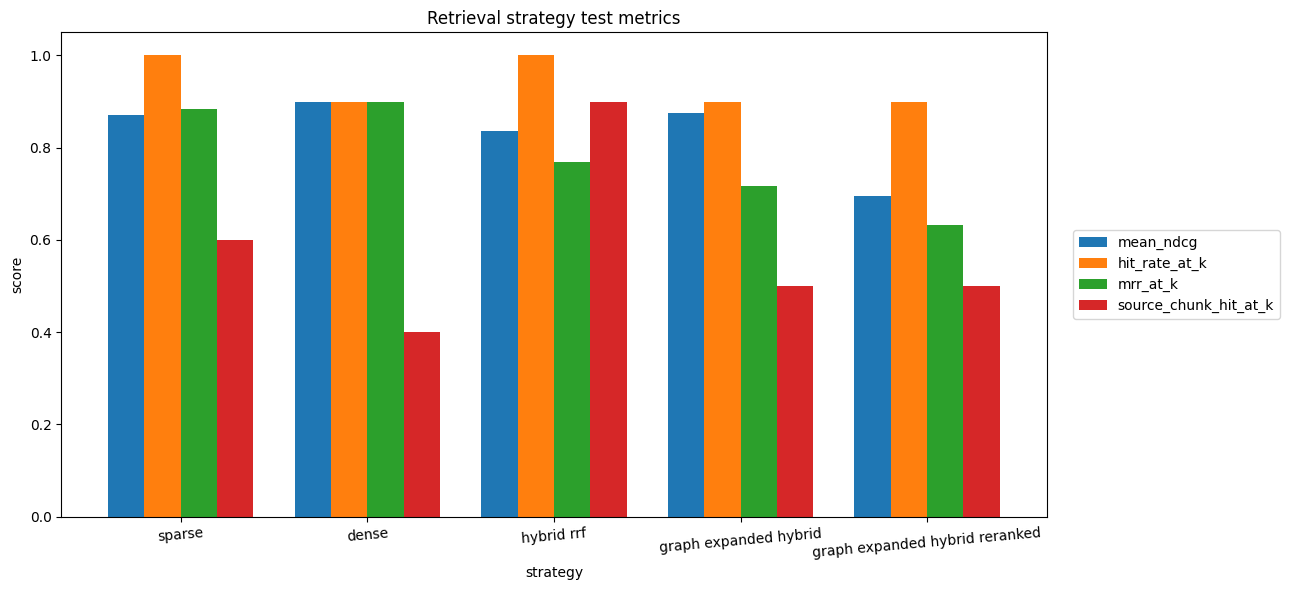

In [61]:
if "retrieval_test_metrics_df" not in globals() or retrieval_test_metrics_df.empty:
    print("No legacy LLM-judged metrics are loaded; retrieval-only ablation results remain available above.")
else:
    display(retrieval_test_metrics_df)

    retrieval_test_plot_df = retrieval_test_metrics_df.copy()
    retrieval_test_plot_df["strategy_label"] = retrieval_test_plot_df["strategy"].str.replace("_", " ")

    retrieval_test_plot_ax = retrieval_test_plot_df.plot(
        x="strategy_label",
        y=["mean_ndcg", "hit_rate_at_k", "mrr_at_k", "source_chunk_hit_at_k"],
        kind="bar",
        figsize=(13, 6),
        width=0.78,
        title="Retrieval strategy test metrics",
    )
    retrieval_test_plot_ax.set_xlabel("strategy")
    retrieval_test_plot_ax.set_ylabel("score")
    retrieval_test_plot_ax.set_ylim(0, 1.05)
    retrieval_test_plot_ax.tick_params(axis="x", rotation=5)
    retrieval_test_plot_ax.set_xticklabels(
        retrieval_test_plot_ax.get_xticklabels(),
        ha="center",
    )
    retrieval_test_plot_ax.legend(
        loc="center left",
        bbox_to_anchor=(1.02, 0.5),
        frameon=True,
    )
    retrieval_test_plot_ax.figure.tight_layout()

In [43]:
# Export final retrieval test metrics for thesis reporting and later inspection.
RETRIEVAL_TEST_METRICS_CSV = RETRIEVAL_EXPORT_DIR / "retrieval_test_metrics.csv"
RETRIEVAL_TEST_METRICS_JSONL = RETRIEVAL_EXPORT_DIR / "retrieval_test_metrics.jsonl"

if "retrieval_test_metrics_df" not in globals() or retrieval_test_metrics_df.empty:
    print("Skipping legacy metric export because no LLM-judged metrics are loaded.")
else:
    retrieval_test_metrics_df.to_csv(RETRIEVAL_TEST_METRICS_CSV, index=False)
    with RETRIEVAL_TEST_METRICS_JSONL.open("w", encoding="utf-8") as handle:
        for record in retrieval_test_metrics_df.to_dict(orient="records"):
            handle.write(json.dumps(record, ensure_ascii=False) + "\n")

    display(pd.DataFrame([{
        "csv": str(RETRIEVAL_TEST_METRICS_CSV),
        "jsonl": str(RETRIEVAL_TEST_METRICS_JSONL),
        "rows": len(retrieval_test_metrics_df),
    }]))


,csv,jsonl,rows
0,data\evaluation\retrieval_runs\retrieval_test_...,data\evaluation\retrieval_runs\retrieval_test_...,5
